In [3]:
import numpy as np
import pandas as pd

In [4]:
train=pd.read_csv("C:\\Users\\verseelia\\Desktop\\comment_toxicity\\train.csv")

In [5]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
test=pd.read_csv("C:\\Users\\verseelia\\Desktop\\comment_toxicity\\test.csv")

In [7]:
print("Training data:", train.shape)
print("Testing data:", test.shape)

Training data: (159571, 8)
Testing data: (153164, 2)


In [8]:
train.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [9]:
test.isnull().sum()

id              0
comment_text    0
dtype: int64

In [10]:
train["comment_text"].duplicated().sum()

np.int64(0)

In [11]:
test["comment_text"].duplicated().sum()

np.int64(0)

In [12]:
train.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='str')

In [13]:
target_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

In [14]:
train[target_columns].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

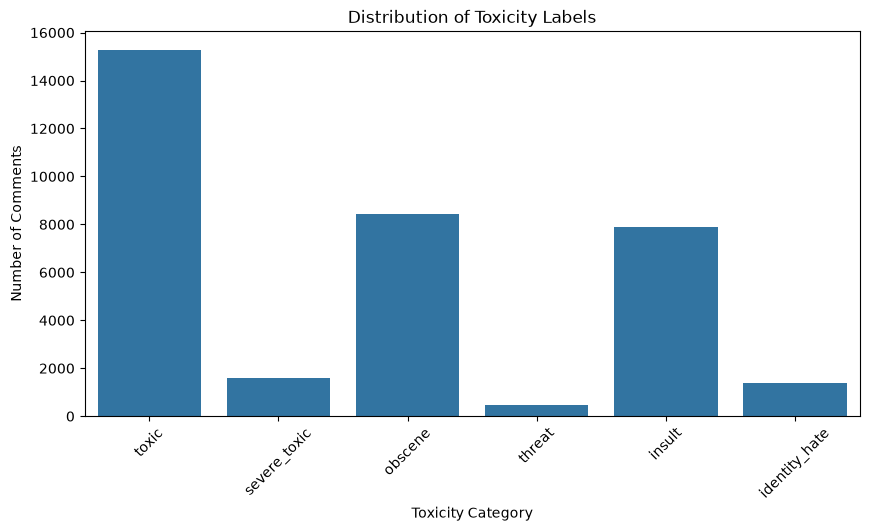

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
label_counts = train[target_columns].sum()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=label_counts.index,
    y=label_counts.values
)

plt.title("Distribution of Toxicity Labels")
plt.xlabel("Toxicity Category")
plt.ylabel("Number of Comments")

plt.xticks(rotation=45)
plt.show()

## Exploratory Data Analysis: Toxicity Label Distribution

The dataset contains six toxicity categories: `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, and `identity_hate`.

We first count the number of comments belonging to each toxicity category. Since the labels are binary (`0` or `1`), summing each label column gives the total number of positive examples for that category.

The label distribution shows that the dataset is highly imbalanced. Some categories, such as `toxic`, have many more examples, while categories such as `threat` have very few examples.

Visualizing the label counts helps us understand this imbalance before training the model. This is important because the model may otherwise focus more on common toxicity categories and perform poorly on rare categories.

**Inference:** The toxicity labels are not evenly distributed, so class imbalance needs to be considered during model training.

In [16]:
train["num_labels"] = train[target_columns].sum(axis=1)

In [17]:
train["num_labels"].value_counts().sort_index()

num_labels
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64

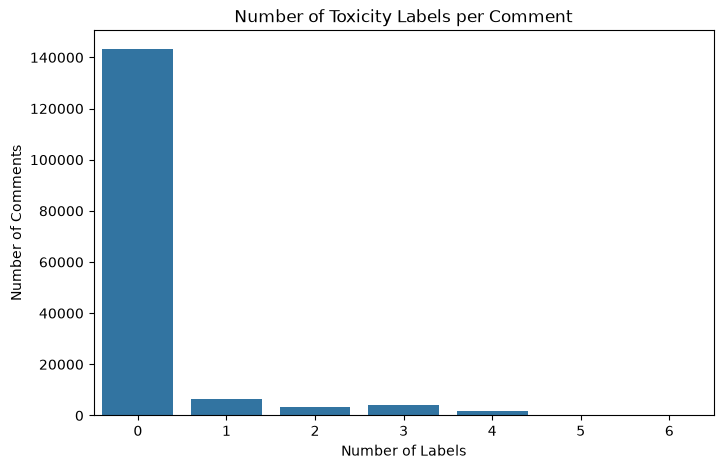

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(x=train["num_labels"])

plt.title("Number of Toxicity Labels per Comment")
plt.xlabel("Number of Labels")
plt.ylabel("Number of Comments")

plt.show()

## Exploratory Data Analysis: Number of Toxicity Labels per Comment

Since this is a multi-label classification problem, a comment can belong to more than one toxicity category.

We calculate the total number of positive toxicity labels for each comment by summing the six target columns across each row. The resulting `num_labels` column represents how many toxicity categories are assigned to each comment.

For example, if a comment has `toxic = 1`, `obscene = 1`, and `insult = 1`, then its `num_labels` value is 3.

The count plot shows how toxicity labels are distributed across individual comments, including comments with no toxic labels and comments with multiple toxicity labels.

**Inference:** The dataset contains comments with different numbers of toxicity labels, confirming that a comment can have multiple toxicity categories simultaneously. This supports treating the problem as a multi-label classification task rather than a single-label classification problem.

In [19]:
train[train["num_labels"] > 1][
    ["comment_text"] + target_columns
].head(10)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
42,You are gay or antisemmitian? \n\nArchangel WH...,1,0,1,0,1,1
43,"FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!",1,0,1,0,1,0
51,GET FUCKED UP. GET FUCKEEED UP. GOT A DRINK T...,1,0,1,0,0,0
55,Stupid peace of shit stop deleting my stuff as...,1,1,1,0,1,0
56,=Tony Sidaway is obviously a fistfuckee. He lo...,1,0,1,0,1,0
58,My Band Page's deletion. You thought I was gon...,1,0,1,0,0,0
65,All of my edits are good. Cunts like you who ...,1,0,1,0,1,0
79,Hi! I am back again!\nLast warning!\nStop undo...,1,0,0,1,0,0
86,"Would you both shut up, you don't run wikipedi...",1,0,0,0,1,0


In [20]:
train["char_count"] = train["comment_text"].apply(len)

In [21]:
train["char_count"].describe()

count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: char_count, dtype: float64

## Exploratory Data Analysis: Comment Length

We calculate the number of characters in each comment using the `len()` function and store the result in a new `char_count` column.

The `describe()` function is then used to understand the distribution of comment lengths.

The dataset contains 159,571 comments. The average comment length is approximately 394 characters, while the median is 205 characters. The maximum length is 5,000 characters.

The difference between the mean and median indicates that some comments are considerably longer than most comments.

**Inference:** Comment lengths vary substantially across the dataset. Understanding this distribution is important before text tokenization and sequence preparation, as we need to decide how much text the model should process for each comment.

In [22]:
train["word_count"] = train["comment_text"].apply(
    lambda x: len(x.split())
)

In [23]:
train["word_count"].describe()

count    159571.000000
mean         67.273527
std          99.230702
min           1.000000
25%          17.000000
50%          36.000000
75%          75.000000
max        1411.000000
Name: word_count, dtype: float64

## Exploratory Data Analysis: Word Count Distribution

We calculate the number of words in each comment using `split()` and store the result in a new `word_count` column.

The dataset contains 159,571 comments, with an average of approximately 67 words per comment and a median of 36 words. The longest comment contains 1,411 words.

The difference between the mean and median indicates that some comments are considerably longer than most comments.

**Inference:** The comments have varying word lengths, with a small number of very long comments. Understanding the word-count distribution is important before tokenization and sequence preparation, where comments may need to be padded or truncated to a fixed length.

In [24]:
train["is_toxic"] = train[target_columns].max(axis=1)

In [25]:
train.groupby("is_toxic")["word_count"].mean()

is_toxic
0    68.921065
1    52.717720
Name: word_count, dtype: float64

## Exploratory Data Analysis: Word Count by Toxicity

To compare comment length between toxic and non-toxic comments, we create an `is_toxic` indicator.

A comment is considered toxic (`1`) if at least one of the six toxicity labels is present; otherwise, it is considered non-toxic (`0`). This is calculated using the maximum value across the six target columns.

We then calculate the average word count for both groups.

The results show that non-toxic comments have an average length of approximately 68.92 words, while toxic comments have an average length of approximately 52.72 words.

**Inference:** In this dataset, toxic comments are shorter on average than non-toxic comments. However, comment length alone does not determine whether a comment is toxic. This analysis is used only to understand the relationship between text length and toxicity before model training.

In [26]:
train.groupby("is_toxic")["char_count"].mean()

is_toxic
0    404.347174
1    303.304037
Name: char_count, dtype: float64

## Exploratory Data Analysis: Character Count by Toxicity

We compare the average character count of toxic and non-toxic comments using the `is_toxic` indicator.

The results show that non-toxic comments have an average length of approximately 404 characters, while toxic comments have an average length of approximately 303 characters.

**Inference:** In this dataset, toxic comments are shorter on average than non-toxic comments. This is an observed pattern in the dataset and does not mean that comment length alone determines toxicity. The analysis helps us understand the text characteristics before model training.

In [27]:


train[train["is_toxic"] == 0]["comment_text"].head(10).tolist()

["Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",
 "D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)",
 "Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",
 '"\nMore\nI can\'t make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ""types of accidents""  -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on r

In [28]:
train[train["is_toxic"] == 1]["comment_text"].head(10).tolist()

['COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK',
 'Hey... what is it..\n@ | talk .\nWhat is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIAL and DESTRUCTIVE (non)-contribution at WP?\n\nAsk Sityush to clean up his behavior than issue me nonsensical warnings...',
 "Bye! \n\nDon't look, come or think of comming back! Tosser.",
 "You are gay or antisemmitian? \n\nArchangel WHite Tiger\n\nMeow! Greetingshhh!\n\nUh, there are two ways, why you do erased my comment about WW2, that holocaust was brutally slaying of Jews and not gays/Gypsys/Slavs/anyone...\n\n1 - If you are anti-semitian, than shave your head bald and go to the skinhead meetings!\n\n2 - If you doubt words of the Bible, that homosexuality is a deadly sin, make a pentagram tatoo on your forehead go to the satanistic masses with your gay pals!\n\n3 - First and last warning, you fucking gay - I won't appreciate if any 

In [29]:
import re

special_chars = set()

for text in train["comment_text"]:
    special_chars.update(re.findall(r"[^a-zA-Z\s]", str(text)))

print(sorted(special_chars))

['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~', '\x7f', '\x91', '\x92', '\x93', '\x94', '\x95', '\x97', '\x99', '\x9d', '¡', '¢', '£', '¤', '¥', '¦', '§', '¨', '©', 'ª', '«', '¬', '\xad', '®', '¯', '°', '±', '²', '³', '´', 'µ', '¶', '·', '¸', '¹', 'º', '»', '¼', '½', '¾', '¿', 'À', 'Á', 'Â', 'Ã', 'Ä', 'Å', 'Æ', 'Ç', 'È', 'É', 'Ê', 'Ë', 'Ì', 'Í', 'Î', 'Ï', 'Ð', 'Ñ', 'Ò', 'Ó', 'Ô', 'Õ', 'Ö', '×', 'Ø', 'Ù', 'Ú', 'Û', 'Ü', 'Ý', 'Þ', 'ß', 'à', 'á', 'â', 'ã', 'ä', 'å', 'æ', 'ç', 'è', 'é', 'ê', 'ë', 'ì', 'í', 'î', 'ï', 'ð', 'ñ', 'ò', 'ó', 'ô', 'õ', 'ö', '÷', 'ø', 'ù', 'ú', 'û', 'ü', 'ý', 'þ', 'ÿ', 'Ā', 'ā', 'Ă', 'ă', 'Ą', 'ą', 'Ć', 'ć', 'Ĉ', 'ĉ', 'Ċ', 'ċ', 'Č', 'č', 'Ď', 'ď', 'Đ', 'đ', 'Ē', 'ē', 'Ĕ', 'ĕ', 'Ė', 'ė', 'Ę', 'ę', 'Ě', 'ě', 'Ĝ', 'ĝ', 'Ğ', 'ğ', 'Ġ', 'ġ', 'Ģ', 'ģ', 'Ĥ', 'ĥ', 'Ħ', 'ħ', 'Ĩ', 'ĩ', 'Ī', 'ī', 'Ĭ', 'ĭ', 'Į', 'į'

In [30]:
from collections import Counter

special_char_counts = Counter()

for text in train["comment_text"]:
    special_char_counts.update(
        re.findall(r"[^a-zA-Z\s]", str(text))
    )

print(special_char_counts.most_common())

[('.', 680368), (',', 474958), ('"', 392552), ("'", 219429), ('!', 105576), ('1', 104130), ('-', 102382), ('0', 101296), (':', 95215), (')', 90711), ('(', 85085), ('2', 82627), ('?', 71692), ('/', 58994), ('9', 39668), ('3', 37947), ('5', 35502), ('4', 34769), ('=', 31010), ('8', 30983), ('6', 30056), ('7', 30004), (';', 21899), ('_', 19087), ('|', 14406), (']', 8876), ('[', 8301), ('~', 7770), ('&', 6735), ('—', 6450), ('{', 6426), ('#', 6232), ('}', 6082), ('•', 5890), ('%', 5702), ('*', 5275), ('’', 3854), ('+', 3301), ('–', 2774), ('“', 2301), ('”', 2267), ('>', 1668), ('@', 1654), ('·', 1519), ('é', 1211), ('$', 977), ('^', 815), ('\u200e', 647), ('→', 645), ('`', 574), ('\\', 572), ('´', 550), ('<', 528), ('‘', 525), ('а', 499), ('о', 482), ('á', 417), ('…', 409), ('е', 381), ('и', 380), ('ü', 379), ('ö', 341), ('н', 327), ('ا', 323), ('í', 311), ('α', 279), ('р', 278), ('ı', 264), ('ó', 257), ('ل', 250), ('т', 246), ('с', 239), ('ä', 221), ('ć', 217), ('к', 213), ('ç', 211), ('♥

## Exploratory Data Analysis: Special Character Analysis

This step analyzes the frequency of special characters and punctuation present in the comments.

The purpose is to understand the text structure before applying preprocessing. Special characters such as punctuation and symbols may contain useful information for toxicity prediction, so they should not be removed without analysis.

**Inference:** The dataset contains various special characters and punctuation marks. Their distribution should be considered before deciding on text preprocessing.

In [31]:
import re
import html

In [32]:
def clean_text(text):
    
    # Convert to string
    text = str(text)
    
    # Decode HTML entities
    text = html.unescape(text)
    
    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    
    # Remove zero-width and control characters
    text = re.sub(r"[\u200b-\u200f\u202a-\u202e\u2060\ufeff]", "", text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Normalize multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [33]:
sample = train["comment_text"].iloc[90]

print("BEFORE:")
print(sample)

print("\nAFTER:")
print(clean_text(sample))

BEFORE:
Personal attacks in Fruit Brute VfD 

My apologies if I'm being to critical, but I feel that many of the comments made in the Fruit Brute VfD debate were far from reasonable.  There had to be a more diplomatic way to disagree with 's assertion on the initial sentence than don't lie, it makes you look even more juvenile.... Learn to face up to when you've goofed, it will go a long way in your life  The attacks do to his age certainly border on a personal attack.  Were Bart133 forty, sixty, or eighty, would you have included the comment on how 'juvenile' he is?

I don't expect you to apologise to anyone, but I want to make it clear that I consider your comments in this VfD debate inappropriate, and I think their are many members of the community who would agree with me.   talk 06:46, 2005 Feb 7 (UTC)

AFTER:
personal attacks in fruit brute vfd my apologies if i'm being to critical, but i feel that many of the comments made in the fruit brute vfd debate were far from reasonable. t

In [34]:
for text in train["comment_text"].sample(5, random_state=42):
    print("BEFORE:")
    print(text)
    
    print("\nAFTER:")
    print(clean_text(text))
    
    print("=" * 80)

BEFORE:
Geez, are you forgetful!  We've already discussed why Marx  was  not an anarchist, i.e. he wanted to use a State to mold his 'socialist man.'  Ergo, he is a statist - the opposite of an  anarchist.  I know a guy who says that, when he gets old and his teeth fall out, he'll quit eating meat.  Would you call him a vegetarian?

AFTER:
geez, are you forgetful! we've already discussed why marx was not an anarchist, i.e. he wanted to use a state to mold his 'socialist man.' ergo, he is a statist - the opposite of an anarchist. i know a guy who says that, when he gets old and his teeth fall out, he'll quit eating meat. would you call him a vegetarian?
BEFORE:
Carioca RFA 

Thanks for your support on my request for adminship.

The final outcome was (31/4/1), so I am now an administrator. If you have any comments or concerns on my actions as an administrator, please let me know. Thank you!

AFTER:
carioca rfa thanks for your support on my request for adminship. the final outcome was (31

In [35]:
train["clean_comment"] = train["comment_text"].apply(clean_text)
test["clean_comment"] = test["comment_text"].apply(clean_text)

## Text Preprocessing

This step performs basic cleaning and normalization of the raw comments. HTML entities and tags, invisible/control characters, inconsistent capitalization, and unnecessary spaces are handled to make the text more consistent.

The original comments are preserved, while the cleaned versions are stored in a new `clean_comment` column for both the training and test datasets.

**Inference:** The text has been standardized while preserving its meaningful content, making it ready for the next stage of text processing and tokenization.

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X = train["clean_comment"]
y = train[target_columns]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 127656
Validation samples: 31915


In [39]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (127656,)
y_train: (127656, 6)
X_val: (31915,)
y_val: (31915, 6)


In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Total unique words:", len(tokenizer.word_index))

Total unique words: 182456


## Text Tokenization and Vocabulary Creation

The cleaned training comments are used to build a tokenizer vocabulary. Each unique word is assigned a numerical index so that the text can later be converted into numerical sequences for the neural network.

An `<OOV>` (Out Of Vocabulary) token is included to handle words that are not present in the training vocabulary.

The tokenizer identified 182,456 unique words in the training data.

**Inference:** The text has been converted from raw words into a numerical vocabulary representation, which is required for neural network-based text classification.

In [41]:
from collections import Counter

word_counts = Counter(tokenizer.word_counts)

print("Total unique words:", len(word_counts))

print("\nMost common words:")
print(word_counts.most_common(20))

Total unique words: 182455

Most common words:
[('the', 398920), ('to', 238924), ('of', 180404), ('and', 180243), ('a', 172567), ('you', 164367), ('i', 164218), ('is', 141389), ('that', 123716), ('in', 117045), ('it', 104576), ('for', 82535), ('this', 78333), ('not', 75162), ('on', 72284), ('be', 66738), ('as', 62200), ('have', 57909), ('are', 57665), ('your', 50486)]


In [42]:
# word_counts

In [43]:
single_occurrence = sum(
    1 for count in word_counts.values()
    if count == 1
)

print("Words appearing only once:", single_occurrence)

print(
    "Percentage appearing only once:",
    round(single_occurrence / len(word_counts) * 100, 2),
    "%"
)

Words appearing only once: 98703
Percentage appearing only once: 54.1 %


## Vocabulary Frequency Analysis

This step analyzes the frequency of words in the training vocabulary and identifies words that appear only once.

Out of the 182,456 unique words, 98,703 words (54.1%) occur only once in the training dataset.

**Inference:** A large portion of the vocabulary consists of rare words. This indicates that using the entire vocabulary may be inefficient, so limiting the vocabulary to frequently occurring words can help reduce unnecessary vocabulary size and improve model efficiency.

In [ ]:
total_occurrences = sum(word_counts.values())

for vocab_size in [10000, 30000, 50000, 100000]:
    top_words = sum(
        count
        for _, count in word_counts.most_common(vocab_size)
    )

    coverage = (top_words / total_occurrences) * 100

    print(
        f"Top {vocab_size:,} words cover "
        f"{coverage:.2f}% of all word occurrences"
    )

Top 10,000 words cover 93.45% of all word occurrences
Top 30,000 words cover 96.99% of all word occurrences
Top 50,000 words cover 98.01% of all word occurrences
Top 100,000 words cover 99.06% of all word occurrences


### Vocabulary Size Selection

To select an appropriate vocabulary size for the LSTM model, word-frequency coverage was analyzed.

| Vocabulary Size | Corpus Coverage |
|---:|---:|
| 10,000 | 93.45% |
| 30,000 | 96.99% |
| 50,000 | 98.01% |
| 100,000 | 99.06% |

The top **50,000 words cover 98.01% of all word occurrences** in the dataset. Increasing the vocabulary from 50,000 to 100,000 words improves coverage by only about **1.05 percentage points**, while doubling the vocabulary size and increasing the model's memory requirements.

Therefore, a vocabulary size of **50,000** was selected as a balance between vocabulary coverage and model complexity.

> **Conclusion:** `vocab_size = 50,000` was chosen because it captures 98.01% of word occurrences while keeping the model computationally manageable.

In [45]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=50000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

## Tokenization and Vocabulary

The text data was converted into numerical sequences using the Keras `Tokenizer`.

- **Vocabulary size:** 50,000
- **OOV token:** `<OOV>`
- The tokenizer was fitted only on the training data to avoid data leakage.

The vocabulary size of 50,000 was selected based on word-frequency coverage analysis. The top 50,000 words cover **98.01% of all word occurrences** in the dataset. This provides high vocabulary coverage while keeping the model computationally manageable.

The `<OOV>` token is used for words that are not included in the selected 50,000-word vocabulary.

**Tokenizer configuration:**

```python
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=50000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [46]:
print("Total unique words:", len(tokenizer.word_index))
print("Vocabulary size used:", tokenizer.num_words)

Total unique words: 182456
Vocabulary size used: 50000


In [47]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

In [48]:
X_val_seq = tokenizer.texts_to_sequences(X_val)

In [49]:
X_test_seq = tokenizer.texts_to_sequences(test["clean_comment"])

## Converting Text into Sequences

After fitting the tokenizer, the text comments were converted into numerical sequences.

Each word is replaced with its corresponding integer ID from the tokenizer's vocabulary.

- `X_train` → training sequences
- `X_val` → validation sequences
- `test["clean_comment"]` → test sequences

The same fitted tokenizer is used for all three datasets to ensure that the word-to-index mapping remains consistent.

In [50]:
print("Original:")
print(X_train.iloc[0])

print("\nSequence:")
print(X_train_seq[0])

Original:
grandma terri should burn in trash grandma terri is trash. i hate grandma terri. f%%k her to hell! 71.74.76.40

Sequence:
[12915, 8288, 57, 3979, 11, 4413, 12915, 8288, 9, 4413, 8, 399, 12915, 8288, 871, 1367, 185, 3, 866, 1699, 2585, 1738, 1336]


In [51]:
train_lengths = [len(seq) for seq in X_train_seq]

print("Minimum length:", min(train_lengths))
print("Maximum length:", max(train_lengths))
print("Average length:", np.mean(train_lengths))
print("Median length:", np.median(train_lengths))

Minimum length: 0
Maximum length: 1403
Average length: 68.40968697123519
Median length: 36.0


## Comment Length Analysis

The tokenized training comments have the following length statistics:

| Statistic | Value |
|---|---:|
| Minimum length | 0 |
| Maximum length | 1,403 |
| Average length | 68.41 |
| Median length | 36 |

The **median comment length is 36 tokens**, while the average is higher at 68.41 because some comments are much longer.

The maximum length is 1,403 tokens, but padding every comment to 1,403 would make the model unnecessarily large and computationally expensive.

Therefore, a suitable `maxlen` should be selected to retain most of the useful information while avoiding excessive padding.

In [52]:
zero_indices = [i for i, seq in enumerate(X_train_seq) if len(seq) == 0]

print("Number of zero-length sequences:", len(zero_indices))

Number of zero-length sequences: 1


In [53]:
for i in zero_indices:
    print("Index:", i)
    print("Original comment:")
    print(repr(X_train.iloc[i]))
    print("Sequence:", X_train_seq[i])

Index: 88664
Original comment:
''
Sequence: []


In [54]:
empty_mask = X_train.str.strip() != ""

X_train = X_train[empty_mask]
y_train = y_train.loc[X_train.index]

## Handling Empty Comments

During sequence-length analysis, one training comment was found with a sequence length of **0**.

The original comment at index `88664` was an empty string (`''`), so the tokenizer produced an empty sequence (`[]`).

Since an empty comment does not provide any meaningful text information for toxicity classification, it was removed from the training data.

The corresponding target label was also removed using the same index to keep `X_train` and `y_train` correctly aligned.

**Result:** One empty comment was removed from the training dataset.

In [55]:
print("Training samples after removing empty comments:", len(X_train))

Training samples after removing empty comments: 127655


In [56]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(test["clean_comment"])

In [57]:
train_lengths = [len(seq) for seq in X_train_seq]

print("Minimum length:", min(train_lengths))
print("Maximum length:", max(train_lengths))
print("Average length:", np.mean(train_lengths))
print("Median length:", np.median(train_lengths))

Minimum length: 1
Maximum length: 1403
Average length: 68.41022286631937
Median length: 36.0


In [58]:
for p in [90, 95, 98, 99]:
    print(
        f"{p}th percentile:",
        int(np.percentile(train_lengths, p))
    )

90th percentile: 155
95th percentile: 233
98th percentile: 396
99th percentile: 582


## Selecting the Maximum Sequence Length

Percentiles of the training comment lengths were analyzed to determine a suitable maximum sequence length.

| Percentile | Sequence Length |
|---|---:|
| 90th | 155 |
| 95th | 233 |
| 98th | 396 |
| 99th | 582 |

The **95th percentile is 233 tokens**, meaning approximately 95% of the comments contain 233 tokens or fewer.

The **98th percentile is 396 tokens**, meaning approximately 98% of the comments contain 396 tokens or fewer.

Using the maximum length of 1,403 would result in excessive padding for most comments. Therefore, selecting a value around the **95th–98th percentile** provides a good balance between retaining information from longer comments and keeping the model computationally efficient.

In [59]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LENGTH = 233

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

## Padding and Truncating Sequences

A maximum sequence length of **233 tokens** was selected based on the 95th percentile of the training comment lengths.

All sequences were converted to a fixed length of 233 tokens.

- **Padding:** `post` — zeros are added at the end of shorter sequences.
- **Truncating:** `post` — tokens beyond 233 are removed from longer sequences.
- This ensures that all comments have the same input shape for the LSTM model.

Approximately **95% of the training comments are fully retained**, while only the longer comments are truncated.

This fixed-length representation makes the input suitable for batch processing while controlling computational cost.

In [60]:
print("X_train shape:", X_train_pad.shape)
print("X_val shape:", X_val_pad.shape)
print("X_test shape:", X_test_pad.shape)

X_train shape: (127655, 233)
X_val shape: (31915, 233)
X_test shape: (153164, 233)


In [61]:
print(y_train.shape)
print(y_val.shape)

(127655, 6)
(31915, 6)


In [75]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout

VOCAB_SIZE = 50000
EMBEDDING_DIM = 128

model = Sequential([
    
    Input(shape=(MAX_LENGTH,)),
    
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    
    Bidirectional(
        LSTM(64)
    ),
    
    Dropout(0.3),
    
    Dense(32, activation="relu"),
    
    Dense(6, activation="sigmoid")
])

In [76]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 233, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,503,142 (24.81 MB)

 Trainable params: 6,503,142 (24.81 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [79]:
BATCH_SIZE = 64
EPOCHS = 5
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 387s 192ms/step - accuracy: 0.9704 - loss: 0.0672 - val_accuracy: 0.9941 - val_loss: 0.0487
Epoch 2/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 387s 194ms/step - accuracy: 0.9921 - loss: 0.0448 - val_accuracy: 0.9941 - val_loss: 0.0470
Epoch 3/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 386s 193ms/step - accuracy: 0.9751 - loss: 0.0387 - val_accuracy: 0.9937 - val_loss: 0.0481
Epoch 4/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 391s 196ms/step - accuracy: 0.9649 - loss: 0.0332 - val_accuracy: 0.9917 - val_loss: 0.0525
Epoch 5/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 389s 195ms/step - accuracy: 0.8967 - loss: 0.0283 - val_accuracy: 0.9808 - val_loss: 0.0556


## Building and Training the BiLSTM Model

A **Bidirectional LSTM (BiLSTM)** model was built to classify comments into six toxicity categories: `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, and `identity_hate`.

### Model Architecture

The model consists of the following layers:

1. **Input Layer**  
   Accepts sequences of length **233 tokens**.

2. **Embedding Layer**  
   Converts each word ID into a **128-dimensional vector**.  
   The vocabulary contains up to **50,000 words**.

3. **Bidirectional LSTM**  
   Uses **64 LSTM units** and processes the comment in both forward and backward directions. This helps the model understand the context of words from both sides.

4. **Dropout (0.3)**  
   Randomly drops 30% of the connections during training to help reduce overfitting.

5. **Dense Layer**  
   Contains **32 neurons** with ReLU activation to learn higher-level patterns.

6. **Output Layer**  
   Contains **6 neurons**, one for each toxicity category.  
   The sigmoid activation produces an independent probability for each category because a comment can belong to multiple toxicity categories at the same time.

### Model Compilation

The model was compiled using the **Adam optimizer** and **Binary Cross-Entropy loss**.

Binary Cross-Entropy is appropriate because this is a **multi-label classification problem**, where each toxicity label is treated independently.

### Training Results

The model was trained for **5 epochs**.

| Epoch | Training Loss | Training Accuracy | Validation Loss | Validation Accuracy |
|---:|---:|---:|---:|---:|
| 1 | 0.0672 | 0.9704 | 0.0487 | 0.9941 |
| 2 | 0.0448 | 0.9921 | 0.0470 | 0.9941 |
| 3 | 0.0387 | 0.9751 | 0.0481 | 0.9937 |
| 4 | 0.0332 | 0.9649 | 0.0525 | 0.9917 |
| 5 | 0.0283 | 0.8967 | 0.0556 | 0.9808 |

The validation loss was lowest at **Epoch 2 (0.0470)** and the validation accuracy was also highest at **Epoch 1–2 (0.9941)**.

However, accuracy alone is not sufficient for evaluating this model because the toxicity labels are highly imbalanced. In particular, classes such as `threat` and `identity_hate` contain far fewer positive examples.

Therefore, **precision, recall, F1-score, PR curves, and class-specific threshold optimization** will be used for a more meaningful evaluation.

In [80]:
y_val_pred = model.predict(X_val_pad)

998/998 ━━━━━━━━━━━━━━━━━━━━ 66s 64ms/step


In [81]:
print(y_val_pred.shape)

(31915, 6)


In [82]:
y_val_pred_binary = (y_val_pred >= 0.5).astype(int)

In [83]:
print(y_val_pred_binary.shape)

(31915, 6)


In [84]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_val_pred_binary,
        target_names=target_columns,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        toxic       0.80      0.77      0.78      3056
 severe_toxic       0.52      0.40      0.45       321
      obscene       0.80      0.82      0.81      1715
       threat       0.00      0.00      0.00        74
       insult       0.72      0.69      0.71      1614
identity_hate       0.49      0.27      0.35       294

    micro avg       0.77      0.72      0.74      7074
    macro avg       0.56      0.49      0.52      7074
 weighted avg       0.75      0.72      0.73      7074
  samples avg       0.07      0.07      0.06      7074



## Baseline BiLSTM Evaluation

The trained BiLSTM model was evaluated on the validation set using a default classification threshold of **0.5**.

The model produces a probability for each of the six toxicity labels. A probability of **0.5 or higher** was converted into a positive prediction.

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|---|---:|---:|---:|---:|
| toxic | 0.80 | 0.77 | 0.78 | 3,056 |
| severe_toxic | 0.52 | 0.40 | 0.45 | 321 |
| obscene | 0.80 | 0.82 | 0.81 | 1,715 |
| threat | 0.00 | 0.00 | 0.00 | 74 |
| insult | 0.72 | 0.69 | 0.71 | 1,614 |
| identity_hate | 0.49 | 0.27 | 0.35 | 294 |

### Interpretation

The model performs reasonably well on the more frequent classes such as **toxic**, **obscene**, and **insult**.

However, performance is much weaker for the minority classes:

- **Threat:** F1-score = 0.00. The model did not correctly identify any positive `threat` examples at the 0.5 threshold.
- **Identity hate:** F1-score = 0.35, with a recall of only 0.27.
- **Severe toxic:** F1-score = 0.45, with a recall of 0.40.

This shows the impact of the **severe class imbalance** in the dataset. The minority classes have much fewer positive examples, making them harder for the model to identify.

### Why Accuracy Is Misleading

The validation accuracy was around **99%**, which initially appears excellent. However, the classification report shows that the model completely misses the `threat` class.

This happens because most comments are **non-toxic**, so a model can achieve very high accuracy by predicting negative for many examples while still performing poorly on the rare toxicity categories.

Therefore, accuracy is not a suitable primary metric for this multi-label, highly imbalanced classification problem.

The **macro F1-score of 0.52** provides a better indication of overall class-level performance because it gives equal importance to each toxicity category.

The **micro F1-score of 0.74** reflects overall performance across all individual label predictions, but it can still be influenced more by the frequent classes.

### Conclusion

The default **0.5 threshold is not optimal for all six toxicity classes**. Since each class has a different level of imbalance and prediction behavior, class-specific thresholds can be optimized using **Precision-Recall curves and F1-score**.




In [85]:
y_train

,toxic,severe_toxic,obscene,threat,insult,identity_hate
140030,1,0,0,0,0,0
159124,0,0,0,0,0,0
60006,0,0,0,0,0,0
65432,0,0,0,0,0,0
154979,0,0,0,0,0,0
...,...,...,...,...,...,...
119879,0,0,0,0,0,0
103694,0,0,0,0,0,0
131932,1,0,0,0,0,0
146867,0,0,0,0,0,0


In [86]:
import pandas as pd

label_counts = y_train.sum(axis=0)

print("Positive samples per class:")
print(label_counts)

Positive samples per class:
toxic            12238
severe_toxic      1274
obscene           6734
threat             404
insult            6263
identity_hate     1111
dtype: int64


## Positive Samples and Class Imbalance

In this multi-label classification problem, a **positive sample** means a comment that has a particular toxicity label marked as `1`.

For example, if a comment has:

- `toxic = 1` → it is a positive sample for the `toxic` class.
- `threat = 0` → it is not a positive sample for the `threat` class.

The number of positive samples in the training data is:

| Class | Positive Samples |
|---|---:|
| toxic | 12,238 |
| severe_toxic | 1,274 |
| obscene | 6,734 |
| threat | 404 |
| insult | 6,263 |
| identity_hate | 1,111 |

The classes have very different numbers of positive samples, indicating **strong class imbalance**.

For example, the model has 12,238 positive examples to learn the `toxic` class, but only 404 positive examples for the `threat` class.

This imbalance can make it difficult for the model to learn minority classes effectively. This is consistent with the earlier evaluation, where `toxic` had an F1-score of **0.78**, while `threat` had an F1-score of **0.00**.

Therefore, class imbalance needs to be considered when improving the model, particularly for minority classes such as `threat` and `identity_hate`.

In [88]:
import numpy as np

label_names = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

label_counts = np.sum(y_train, axis=0)

negative_counts = len(y_train) - label_counts

pos_weights = negative_counts / label_counts

for label, weight in zip(label_names, pos_weights):
    print(f"{label}: {weight:.2f}")

toxic: 9.43
severe_toxic: 99.20
obscene: 17.96
threat: 314.98
insult: 19.38
identity_hate: 113.90


## Calculating Class Weights

Because the training data is highly imbalanced, class weights were calculated to give more importance to positive examples from minority classes during training.

For each toxicity class:

**Positive samples** = comments where the label is `1`

**Negative samples** = comments where the label is `0`

The positive class weight was calculated as:

**Positive Weight = Number of Negative Samples / Number of Positive Samples**

The calculated weights are:

| Class | Positive Weight |
|---|---:|
| toxic | 9.43 |
| severe_toxic | 99.20 |
| obscene | 17.96 |
| threat | 314.98 |
| insult | 19.38 |
| identity_hate | 113.90 |

The weights are higher for classes with fewer positive examples.

For example, `threat` has only **404 positive samples**, so it receives a much higher weight of **314.98**. This tells the model that making a mistake on a positive `threat` example should be penalized much more than making a mistake on a common class.

Similarly, `toxic` has many more positive samples, so its weight is much smaller at **9.43**.

These weights are used in the **weighted Binary Cross-Entropy loss** so that minority classes receive greater importance during model training.

### Why Are These Weights Needed?

Without class weighting, the model may focus mainly on frequent classes and largely ignore rare classes. Class weighting helps the model pay more attention to minority classes such as `threat`, `identity_hate`, and `severe_toxic`.

The weights are **calculated from the actual class distribution in the training data**, rather than being chosen randomly.

In [89]:
import tensorflow as tf

def weighted_binary_crossentropy(pos_weights):
    
    pos_weights = tf.constant(pos_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        
        y_pred = tf.clip_by_value(
            y_pred,
            tf.keras.backend.epsilon(),
            1 - tf.keras.backend.epsilon()
        )

        loss = -(
            pos_weights * y_true * tf.math.log(y_pred)
            +
            (1 - y_true) * tf.math.log(1 - y_pred)
        )

        return tf.reduce_mean(loss, axis=-1)

    return loss

## Weighted Binary Cross-Entropy Loss

To handle the class imbalance, a **weighted Binary Cross-Entropy loss** was implemented.

Standard Binary Cross-Entropy treats positive and negative predictions equally. However, in this dataset, some positive classes are much rarer than others.

The weighted loss gives a higher penalty when the model incorrectly predicts a positive example for a minority class.

### Formula

For each class, the loss is calculated as:

**Loss = − [ Positive Weight × y_true × log(y_pred) + (1 − y_true) × log(1 − y_pred) ]**

Where:

- **`y_true`** = actual label (`0` or `1`)
- **`y_pred`** = predicted probability between `0` and `1`
- **`Positive Weight`** = weight calculated from the class imbalance
- **`log(y_pred)`** = contribution when the actual label is positive (`y_true = 1`)
- **`log(1 − y_pred)`** = contribution when the actual label is negative (`y_true = 0`)

### How the Formula Works

If the actual label is **1**:

**Loss = − Positive Weight × log(y_pred)**

The positive weight is applied, so mistakes on positive examples of minority classes receive a larger penalty.

If the actual label is **0**:

**Loss = − log(1 − y_pred)**

The positive weight is not applied to negative examples.

### Example

Suppose the actual label is:

**`y_true = 1`**

and the model predicts:

**`y_pred = 0.1`**

This is a poor prediction because the model should have predicted a high probability.

For the `threat` class, the positive weight is **314.98**.

Therefore, the positive loss is multiplied by **314.98**, making this mistake much more important during training.

For a common class such as `toxic`, the positive weight is only **9.43**, so the same type of error receives a smaller weight.

### Why Do We Clip `y_pred`?

The prediction is clipped between a very small value and a value just below 1.

This prevents mathematical problems when calculating:

- `log(0)`
- `log(1 − 1)`

Both would result in undefined values.

### Why `reduce_mean`?

The loss is calculated separately for the six toxicity classes. `tf.reduce_mean(loss, axis=-1)` takes the average of the six class losses for each comment, producing one overall loss value per sample.

This weighted loss allows the model to pay more attention to positive examples from minority toxicity classes while still learning from the negative examples.

In [90]:
model = Sequential([
    Input(shape=(MAX_LENGTH,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(6, activation="sigmoid")
])

In [91]:
model.compile(
    optimizer="adam",
    loss=weighted_binary_crossentropy(pos_weights),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

In [92]:
BATCH_SIZE = 64
EPOCHS = 5

history_weighted = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 506s 252ms/step - accuracy: 0.8968 - loss: 0.5232 - val_accuracy: 0.9171 - val_loss: 0.3593
Epoch 2/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 533s 267ms/step - accuracy: 0.9240 - loss: 0.3238 - val_accuracy: 0.9307 - val_loss: 0.3505
Epoch 3/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 528s 265ms/step - accuracy: 0.9369 - loss: 0.2560 - val_accuracy: 0.9224 - val_loss: 0.3494
Epoch 4/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 484s 243ms/step - accuracy: 0.9468 - loss: 0.2140 - val_accuracy: 0.9555 - val_loss: 0.5111
Epoch 5/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 471s 236ms/step - accuracy: 0.9539 - loss: 0.1879 - val_accuracy: 0.9438 - val_loss: 0.4616


## Training the BiLSTM with Weighted Loss

The same BiLSTM architecture was trained again, but this time the **weighted Binary Cross-Entropy loss** was used to address the class imbalance.

The model architecture was kept unchanged so that the effect of class weighting could be evaluated fairly.

### Training Configuration

- **Optimizer:** Adam
- **Loss:** Weighted Binary Cross-Entropy
- **Batch size:** 64
- **Epochs:** 5
- **Validation data:** `X_val_pad`, `y_val`

### Training Results

| Epoch | Training Loss | Training Accuracy | Validation Loss | Validation Accuracy |
|---:|---:|---:|---:|---:|
| 1 | 0.5232 | 0.8968 | 0.3593 | 0.9171 |
| 2 | 0.3238 | 0.9240 | 0.3505 | 0.9307 |
| 3 | 0.2560 | 0.9369 | 0.3494 | 0.9224 |
| 4 | 0.2140 | 0.9468 | 0.5111 | 0.9555 |
| 5 | 0.1879 | 0.9539 | 0.4616 | 0.9438 |

### Interpretation

The training loss steadily decreased from **0.5232 to 0.1879**, indicating that the model was learning from the training data.

The validation loss reached its lowest value of **0.3494 at Epoch 3**. After this point, the validation loss increased considerably, suggesting that the model may have started to **overfit** the training data.

The validation accuracy fluctuated between **91.71% and 95.55%**. However, accuracy should not be used as the main measure of success because the dataset is highly imbalanced.

The main purpose of introducing the weighted loss was to improve the model's ability to identify **minority toxicity classes**, particularly `threat`, `identity_hate`, and `severe_toxic`.

Therefore, the next step is to evaluate this weighted model using **precision, recall, and F1-score for each class** and compare it with the original unweighted model.

### Important Comparison

The weighted model should not be judged by whether its accuracy is higher or lower than the original model.

Instead, we need to check whether the weighted loss improves performance on the **minority classes** without causing an unacceptable drop in performance on the more frequent classes.

In [93]:
y_pred_prob = model.predict(X_val_pad)

998/998 ━━━━━━━━━━━━━━━━━━━━ 49s 47ms/step


In [94]:
y_pred = (y_pred_prob >= 0.5).astype(int)

In [95]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_pred,
        target_names=label_names,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        toxic       0.52      0.92      0.66      3056
 severe_toxic       0.23      0.91      0.37       321
      obscene       0.48      0.96      0.64      1715
       threat       0.08      0.86      0.14        74
       insult       0.40      0.95      0.56      1614
identity_hate       0.11      0.80      0.20       294

    micro avg       0.39      0.93      0.55      7074
    macro avg       0.30      0.90      0.43      7074
 weighted avg       0.45      0.93      0.60      7074
  samples avg       0.05      0.09      0.06      7074



## Evaluation of the Weighted BiLSTM Model

The weighted BiLSTM model was evaluated on the validation set using the default **0.5 probability threshold**.

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|---|---:|---:|---:|---:|
| toxic | 0.52 | 0.92 | 0.66 | 3,056 |
| severe_toxic | 0.23 | 0.91 | 0.37 | 321 |
| obscene | 0.48 | 0.96 | 0.64 | 1,715 |
| threat | 0.08 | 0.86 | 0.14 | 74 |
| insult | 0.40 | 0.95 | 0.56 | 1,614 |
| identity_hate | 0.11 | 0.80 | 0.20 | 294 |

### What Changed After Using Class Weights?

The weighted loss had a major effect on **recall**.

Recall increased substantially for the minority classes:

- `threat`: **0.00 → 0.86**
- `identity_hate`: **0.27 → 0.80**
- `severe_toxic`: **0.40 → 0.91**

This means the model became much better at **finding actual positive toxicity examples**.

However, this improvement came at the cost of **precision**.

For example:

- `threat` precision = **0.08**
- `identity_hate` precision = **0.11**
- `severe_toxic` precision = **0.23**

This means the model is now predicting many comments as positive even when they are actually negative.

### Why Did This Happen?

The class weights strongly penalized missed positive examples.

For example, the `threat` class had a positive weight of **314.98**.

Therefore, the model learned to be much more sensitive to possible `threat` examples.

At the default threshold of **0.5**, the model is now very willing to classify comments as positive.

So we can see a clear trade-off:

**Before class weighting:**

- High precision
- Low recall
- Minority classes were often missed

**After class weighting:**

- Much higher recall
- Much lower precision
- Minority classes are detected much more frequently

### Macro F1 Comparison

The macro F1-score changed from:

**Unweighted model: 0.52**

to:

**Weighted model: 0.43**

Although recall improved dramatically, precision dropped substantially, causing the overall macro F1-score to decrease.

Therefore, class weighting alone did not give the best final classification performance at the default **0.5 threshold**.

### Key Insight

The weighted model has learned to be **more sensitive** to minority classes, but the default threshold of 0.5 is no longer suitable.

This is why the next step is **class-specific threshold optimization**.

Instead of forcing all six classes to use:

**threshold = 0.5**

we can find a separate threshold for each class that provides a better balance between precision and recall and maximizes the **F1-score**.

This allows us to keep the improved minority-class sensitivity while reducing unnecessary false-positive predictions.

In [96]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

toxic           Best Threshold = 0.937 Best F1 = 0.790
severe_toxic    Best Threshold = 0.966 Best F1 = 0.487
obscene         Best Threshold = 0.936 Best F1 = 0.797
threat          Best Threshold = 0.992 Best F1 = 0.356
insult          Best Threshold = 0.925 Best F1 = 0.713
identity_hate   Best Threshold = 0.949 Best F1 = 0.310


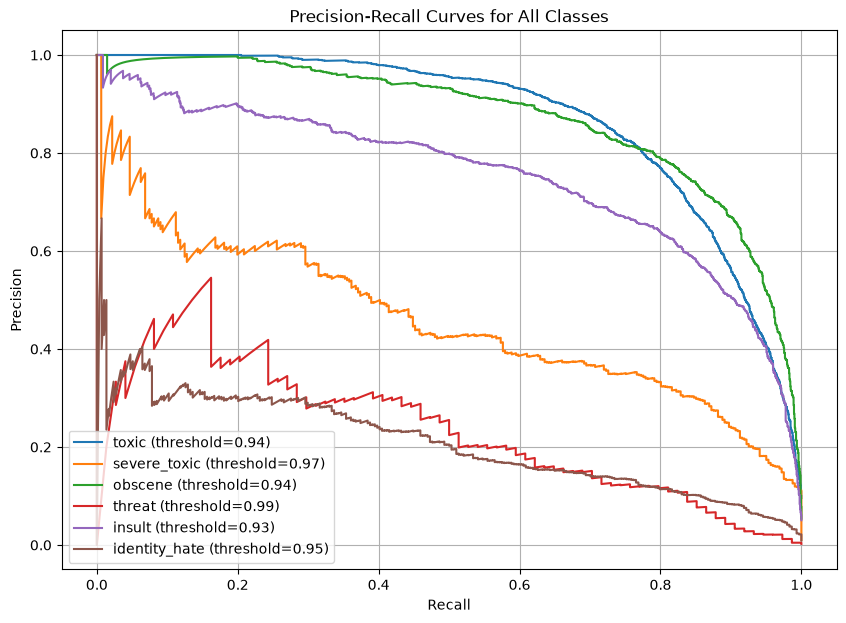

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

class_names = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

best_thresholds = {}

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(class_names):

    # True labels
    y_true_class = y_val.iloc[:, i]

    # Predicted probabilities
    y_prob_class = y_pred_prob[:, i]

    # PR curve
    precision, recall, thresholds = precision_recall_curve(
        y_true_class,
        y_prob_class
    )

    # F1 score for each threshold
    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-8)
    )

    # Best F1
    best_index = np.argmax(f1_scores)

    best_threshold = thresholds[best_index]
    best_f1 = f1_scores[best_index]

    best_thresholds[class_name] = best_threshold

    # Plot
    plt.plot(
        recall,
        precision,
        label=f"{class_name} (threshold={best_threshold:.2f})"
    )

    print(
        f"{class_name:15s} "
        f"Best Threshold = {best_threshold:.3f} "
        f"Best F1 = {best_f1:.3f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for All Classes")
plt.legend()
plt.grid(True)
plt.show()

## Class-Specific Threshold Optimization Using Precision-Recall Curves

After training the weighted BiLSTM model, a default threshold of **0.5** was used for classification.

However, the previous evaluation showed that the weighted model had very high recall but low precision. Therefore, using the same threshold of 0.5 for all six classes was not optimal.

To improve the balance between precision and recall, a **Precision-Recall (PR) curve** was generated separately for each toxicity class.

### Why Use a Precision-Recall Curve?

A PR curve shows how **precision and recall change when the classification threshold changes**.

For example, if the threshold is lowered:

- More comments are classified as positive.
- Recall generally increases.
- Precision may decrease.

If the threshold is increased:

- Fewer comments are classified as positive.
- Precision generally increases.
- Recall may decrease.

Since this is an imbalanced classification problem, the PR curve is more informative than accuracy for evaluating the minority classes.

### Finding the Best Threshold

For each class, the F1-score was calculated at different probability thresholds.

The F1-score combines precision and recall:

**F1 = 2 × (Precision × Recall) / (Precision + Recall)**

The threshold that produced the highest F1-score was selected as the **best threshold for that class**.

### Optimized Thresholds

| Class | Best Threshold | Best F1-Score |
|---|---:|---:|
| toxic | 0.937 | 0.790 |
| severe_toxic | 0.966 | 0.487 |
| obscene | 0.936 | 0.797 |
| threat | 0.992 | 0.356 |
| insult | 0.925 | 0.713 |
| identity_hate | 0.949 | 0.310 |

### Interpretation

The optimal thresholds are very different from the default threshold of 0.5.

For example:

- `toxic` → **0.937**
- `threat` → **0.992**
- `identity_hate` → **0.949**

This means the model's probability outputs are generally high for many comments after applying the strong class weights. Therefore, a much higher threshold is needed to classify a comment as positive while maintaining a better precision-recall balance.

The `threat` class has the highest optimized threshold of **0.992**. This indicates that the model needs to be extremely confident before classifying a comment as `threat`.

### Key Insight

Class weighting helped the model detect minority classes by increasing recall, but it also produced many false positives at the 0.5 threshold.

Class-specific threshold optimization addresses this problem by selecting a different decision boundary for each toxicity category.

Therefore, the final prediction process will use:

**Predicted probability → class-specific threshold → final 0/1 prediction**

rather than applying a single threshold of 0.5 to all classes.

In [103]:
import numpy as np

thresholds = np.array([
    0.937,  # toxic
    0.966,  # severe_toxic
    0.936,  # obscene
    0.992,  # threat
    0.925,  # insult
    0.949   # identity_hate
])

y_pred_tuned = (y_pred_prob >= thresholds).astype(int)

print(y_pred_tuned.shape)


(31915, 6)


## Applying Class-Specific Thresholds

The optimized threshold found for each toxicity class was applied to the validation-set prediction probabilities.

Instead of using a single threshold of **0.5** for all classes, each class now uses its own optimized threshold.

| Class | Threshold |
|---|---:|
| toxic | 0.937 |
| severe_toxic | 0.966 |
| obscene | 0.936 |
| threat | 0.992 |
| insult | 0.925 |
| identity_hate | 0.949 |

For each class, the predicted probability is compared with its corresponding threshold.

If:

**Predicted probability ≥ class threshold → 1 (positive)**

If:

**Predicted probability < class threshold → 0 (negative)**

This produces the final tuned binary predictions for all six toxicity classes.

The resulting `y_pred_tuned` has the same number of rows as the validation data and six columns, with one prediction for each toxicity class.

In [104]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_pred_tuned,
        target_names=class_names,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        toxic       0.82      0.76      0.79      3056
 severe_toxic       0.42      0.57      0.49       321
      obscene       0.78      0.82      0.80      1715
       threat       0.30      0.43      0.35        74
       insult       0.65      0.79      0.71      1614
identity_hate       0.23      0.46      0.31       294

    micro avg       0.69      0.76      0.72      7074
    macro avg       0.53      0.64      0.57      7074
 weighted avg       0.72      0.76      0.74      7074
  samples avg       0.06      0.07      0.06      7074



## Evaluation After Threshold Optimization

The class-specific thresholds were applied to the validation-set probabilities, and the model was evaluated again using precision, recall, and F1-score.

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|---|---:|---:|---:|---:|
| toxic | 0.82 | 0.76 | 0.79 | 3,056 |
| severe_toxic | 0.42 | 0.57 | 0.49 | 321 |
| obscene | 0.78 | 0.82 | 0.80 | 1,715 |
| threat | 0.30 | 0.43 | 0.35 | 74 |
| insult | 0.65 | 0.79 | 0.71 | 1,614 |
| identity_hate | 0.23 | 0.46 | 0.31 | 294 |

### Comparison of the Three Stages

| Metric | Unweighted Model (0.5) | Weighted Model (0.5) | Weighted + Tuned Thresholds |
|---|---:|---:|---:|
| Macro Precision | 0.56 | 0.30 | **0.53** |
| Macro Recall | 0.49 | 0.90 | **0.64** |
| Macro F1 | 0.52 | 0.43 | **0.57** |
| Micro F1 | 0.74 | 0.55 | **0.72** |
| Weighted F1 | 0.73 | 0.60 | **0.74** |

### Interpretation

Threshold optimization substantially improved the balance between precision and recall.

The weighted model at the default 0.5 threshold had extremely high recall (**0.90**) but very low precision (**0.30**). This happened because the class weights encouraged the model to predict minority classes more aggressively.

After applying class-specific thresholds:

- Macro precision increased from **0.30 → 0.53**.
- Macro recall decreased from **0.90 → 0.64**.
- Macro F1 increased from **0.43 → 0.57**.
- Micro F1 increased from **0.55 → 0.72**.
- Weighted F1 increased from **0.60 → 0.74**.

The most important improvement is the increase in **macro F1 from 0.43 to 0.57**. This indicates a better overall balance across the six toxicity classes.

The `threat` class also improved considerably compared with the original unweighted model:

**F1: 0.00 → 0.35**

Similarly, `identity_hate` improved from:

**F1: 0.35 → 0.31**

Although the `identity_hate` F1-score is slightly lower than the original model, its recall increased from **0.27 to 0.46**, meaning the tuned model identifies more actual positive identity-hate examples.

### Final Conclusion

The results show that **class weighting and threshold optimization work together**:

1. **Class weighting** increased sensitivity to minority classes.
2. This caused too many false positives at the default 0.5 threshold.
3. **Class-specific threshold optimization** reduced those false positives.
4. The resulting model achieved a better precision-recall balance and the highest **macro F1-score of 0.57** among the three approaches.

Therefore, the **weighted BiLSTM with class-specific thresholds** is selected as the better configuration compared with the unweighted model and the weighted model using the default 0.5 threshold.

In [113]:
from sklearn.metrics import multilabel_confusion_matrix

cm = multilabel_confusion_matrix(y_val, y_pred_tuned)

for i, class_name in enumerate(class_names):
    print("\n", class_name)
    print(cm[i])


 toxic
[[28353   506]
 [  729  2327]]

 severe_toxic
[[31343   251]
 [  137   184]]

 obscene
[[29796   404]
 [  311  1404]]

 threat
[[31767    74]
 [   42    32]]

 insult
[[29615   686]
 [  339  1275]]

 identity_hate
[[31179   442]
 [  159   135]]


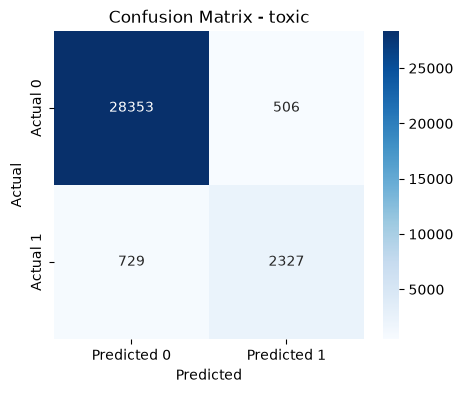

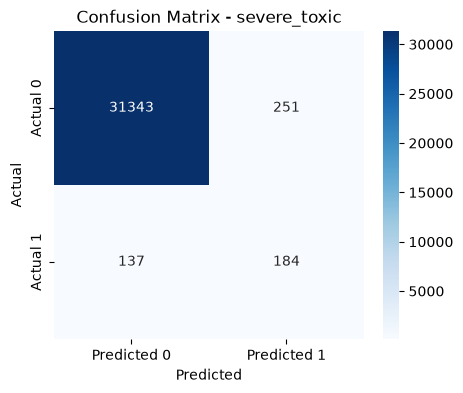

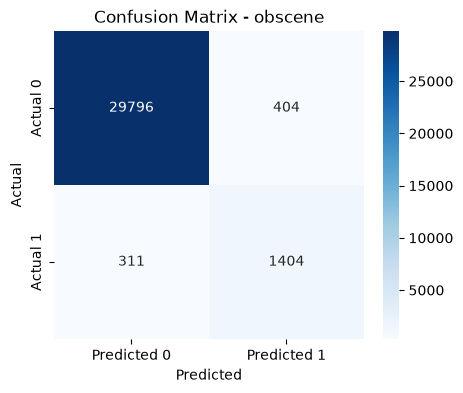

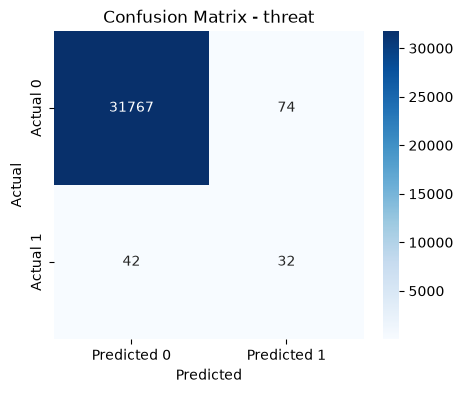

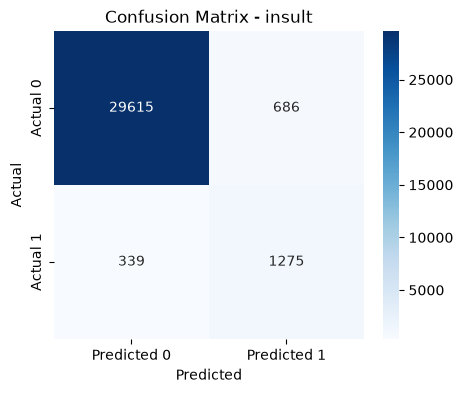

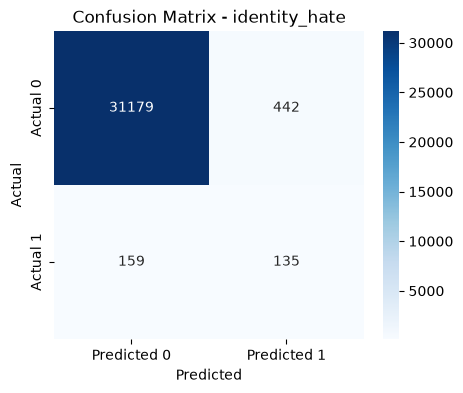

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

cm = multilabel_confusion_matrix(y_val, y_pred_tuned)

for i, class_name in enumerate(class_names):
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        cm[i],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    
    plt.title(f'Confusion Matrix - {class_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [116]:
from sklearn.metrics import average_precision_score
import numpy as np

y_val_np = np.asarray(y_val)

for i, class_name in enumerate(class_names):
    ap = average_precision_score(
        y_val_np[:, i],
        y_pred_prob[:, i]
    )
    
    print(f"{class_name}: PR-AUC = {ap:.4f}")

toxic: PR-AUC = 0.8692
severe_toxic: PR-AUC = 0.4603
obscene: PR-AUC = 0.8704
threat: PR-AUC = 0.2373
insult: PR-AUC = 0.7507
identity_hate: PR-AUC = 0.2089


## Precision-Recall AUC (PR-AUC)

In addition to precision, recall, and F1-score, **Precision-Recall AUC (PR-AUC)** was calculated for each toxicity class.

PR-AUC summarizes the Precision-Recall curve across different classification thresholds. Unlike F1-score, it does not depend on selecting one particular threshold.

This is especially useful for this dataset because the toxicity classes are highly imbalanced.

### PR-AUC Results

| Class | PR-AUC |
|---|---:|
| toxic | 0.8692 |
| severe_toxic | 0.4603 |
| obscene | 0.8704 |
| threat | 0.2373 |
| insult | 0.7507 |
| identity_hate | 0.2089 |

### Interpretation

Higher PR-AUC indicates that the model is better at ranking positive examples above negative examples across different probability thresholds.

The model performs best for:

- **obscene:** 0.8704
- **toxic:** 0.8692
- **insult:** 0.7507

The model performs poorly on the minority classes:

- **severe_toxic:** 0.4603
- **threat:** 0.2373
- **identity_hate:** 0.2089

This is consistent with the earlier classification results. The minority classes have substantially fewer positive training examples, making them harder for the model to distinguish from negative examples.

### Why PR-AUC Is Useful Here

F1-score evaluates performance at **one selected threshold**, whereas PR-AUC considers performance across **many thresholds**.

Therefore:

- **PR-AUC** tells us how well the model separates positive and negative examples across thresholds.
- **F1-score** tells us how well the model performs at a specific chosen threshold.

For this highly imbalanced multi-label problem, PR-AUC provides an additional threshold-independent measure of model performance.

The relatively low PR-AUC for `threat` and `identity_hate` also shows that these classes remain challenging even after class weighting and threshold optimization.

In [123]:
model_128 = Sequential([
    Input(shape=(MAX_LENGTH,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(
        LSTM(128)
    ),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(6, activation="sigmoid")
])

In [124]:
model_128.compile(
    optimizer="adam",
    loss=weighted_binary_crossentropy(pos_weights),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

In [125]:
history_128 = model_128.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    batch_size=64,
    epochs=5
)

Epoch 1/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 970s 477ms/step - accuracy: 0.8859 - loss: 0.5781 - val_accuracy: 0.9041 - val_loss: 0.3808
Epoch 2/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 884s 443ms/step - accuracy: 0.9253 - loss: 0.3218 - val_accuracy: 0.9261 - val_loss: 0.3454
Epoch 3/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 905s 454ms/step - accuracy: 0.9388 - loss: 0.2525 - val_accuracy: 0.9484 - val_loss: 0.4632
Epoch 4/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 1129s 566ms/step - accuracy: 0.9485 - loss: 0.2118 - val_accuracy: 0.9522 - val_loss: 0.4525
Epoch 5/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 1135s 569ms/step - accuracy: 0.9559 - loss: 0.1825 - val_accuracy: 0.9512 - val_loss: 0.4584


## Experiment: Increasing LSTM Units from 64 to 128

To investigate whether a larger LSTM layer could improve the model's ability to learn complex patterns, the number of LSTM units was increased from **64 to 128**.

All other model settings were kept unchanged:

- Vocabulary size: **50,000**
- Embedding dimension: **128**
- LSTM units: **128**
- Bidirectional LSTM
- Dropout: **0.3**
- Dense layer: **32 neurons**
- Output classes: **6**
- Loss: **Weighted Binary Cross-Entropy**
- Optimizer: **Adam**
- Batch size: **64**
- Epochs: **5**

### Training Results

| Epoch | Training Loss | Training Accuracy | Validation Loss | Validation Accuracy |
|---:|---:|---:|---:|---:|
| 1 | 0.5781 | 0.8859 | 0.3808 | 0.9041 |
| 2 | 0.3218 | 0.9253 | **0.3454** | 0.9261 |
| 3 | 0.2525 | 0.9388 | 0.4632 | 0.9484 |
| 4 | 0.2118 | 0.9485 | 0.4525 | **0.9522** |
| 5 | 0.1825 | 0.9559 | 0.4584 | 0.9512 |

### Interpretation

Increasing the LSTM units from **64 to 128** increased the model's capacity to learn patterns from the text.

The training loss decreased consistently from **0.5781 to 0.1825**, showing that the model continued to learn from the training data.

However, the validation loss was lowest at **Epoch 2 (0.3454)** and then increased substantially from Epoch 3 onward.

This indicates that the larger model may be starting to **overfit** after the second epoch. Although validation accuracy increased later, validation loss provides a better indication of how well the model's probability predictions generalize.

The 128-unit model also required substantially more training time per epoch than the 64-unit model. Therefore, increasing the model size did not automatically guarantee better generalization.

The model should therefore be compared with the 64-unit weighted BiLSTM using **class-wise precision, recall, F1-score, and PR-AUC**, rather than relying only on accuracy.

In [126]:
y_pred_prob_128 = model_128.predict(X_val_pad)

998/998 ━━━━━━━━━━━━━━━━━━━━ 80s 78ms/step


In [127]:
y_pred_prob_128.shape

(31915, 6)

In [128]:
from sklearn.metrics import average_precision_score
import numpy as np

y_val_np = np.asarray(y_val)

for i, class_name in enumerate(class_names):
    ap = average_precision_score(
        y_val_np[:, i],
        y_pred_prob_128[:, i]
    )
    print(f"{class_name}: PR-AUC = {ap:.4f}")

toxic: PR-AUC = 0.8708
severe_toxic: PR-AUC = 0.4613
obscene: PR-AUC = 0.8915
threat: PR-AUC = 0.2057
insult: PR-AUC = 0.7632
identity_hate: PR-AUC = 0.2499


### PR-AUC Evaluation – 128-Unit BiLSTM

PR-AUC was calculated for each toxicity class to evaluate the model across different classification thresholds.

| Class | PR-AUC |
|---|---:|
| Toxic | 0.8708 |
| Severe Toxic | 0.4613 |
| Obscene | 0.8915 |
| Threat | 0.2057 |
| Insult | 0.7632 |
| Identity Hate | 0.2499 |

The 128-unit BiLSTM performs well for **toxic, obscene, and insult**, with relatively high PR-AUC values. However, **threat** and **identity hate** remain more difficult to classify because they have fewer positive training samples.

Compared with the previous 64-unit BiLSTM, the 128-unit model improved PR-AUC for **toxic, severe toxic, obscene, insult, and identity hate**, but PR-AUC decreased for **threat**.

Therefore, increasing the LSTM units from 64 to 128 does not guarantee better performance for every class. The final model should be selected based on overall metrics such as **macro F1, class-wise F1, and PR-AUC**, rather than model size alone.

In [129]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

best_thresholds_128 = {}

for i, class_name in enumerate(class_names):

    precision, recall, thresholds = precision_recall_curve(
        y_val_np[:, i],
        y_pred_prob_128[:, i]
    )

    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-8)
    )

    best_idx = np.argmax(f1_scores)

    best_thresholds_128[class_name] = thresholds[best_idx]

    print(
        f"{class_name}: "
        f"threshold = {thresholds[best_idx]:.4f}, "
        f"F1 = {f1_scores[best_idx]:.4f}"
    )

toxic: threshold = 0.8954, F1 = 0.7879
severe_toxic: threshold = 0.9415, F1 = 0.5006
obscene: threshold = 0.9062, F1 = 0.8151
threat: threshold = 0.9792, F1 = 0.3071
insult: threshold = 0.9239, F1 = 0.7196
identity_hate: threshold = 0.9593, F1 = 0.3443


### Class-Specific Threshold Optimization – 128-Unit BiLSTM

The default classification threshold of 0.5 is not ideal for the weighted model because class weighting causes the model to produce higher probability values.

Therefore, a separate threshold was selected for each toxicity class by finding the threshold that gives the highest **F1-score** on the validation set.

| Class | Best Threshold | Best F1 |
|---|---:|---:|
| Toxic | 0.8954 | 0.7879 |
| Severe Toxic | 0.9415 | 0.5006 |
| Obscene | 0.9062 | 0.8151 |
| Threat | 0.9792 | 0.3071 |
| Insult | 0.9239 | 0.7196 |
| Identity Hate | 0.9593 | 0.3443 |

The optimal thresholds are much higher than 0.5 for all six classes. This means that the model needs a relatively high predicted probability before classifying a comment as positive.

The highest F1-score is obtained for **obscene (0.8151)**, followed by **toxic (0.7879)** and **insult (0.7196)**. The lowest F1-scores are for **threat (0.3071)** and **identity hate (0.3443)**, which are also the classes with fewer positive training examples.

These class-specific thresholds will be used for the final validation predictions instead of the default 0.5 threshold.

In [130]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

In [133]:
# history_128_es = model_128.fit(
#     X_train_pad,
#     y_train,
#     validation_data=(X_val_pad, y_val),
#     batch_size=64,
#     epochs=5,
#     callbacks=[early_stopping]
# )

In [134]:
model_rd = Sequential([
    Input(shape=(MAX_LENGTH,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(
        LSTM(
            128,
            recurrent_dropout=0.2
        )
    ),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(6, activation="sigmoid")
])

In [135]:
model_rd.compile(
    optimizer="adam",
    loss=weighted_binary_crossentropy(pos_weights),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

In [136]:
history_rd = model_rd.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    batch_size=64,
    epochs=5
)

Epoch 1/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 1280s 639ms/step - accuracy: 0.8901 - loss: 0.5328 - val_accuracy: 0.9264 - val_loss: 0.3630
Epoch 2/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 1104s 553ms/step - accuracy: 0.9278 - loss: 0.3126 - val_accuracy: 0.9380 - val_loss: 0.3615
Epoch 3/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 1318s 632ms/step - accuracy: 0.9334 - loss: 0.2686 - val_accuracy: 0.9325 - val_loss: 0.3805
Epoch 4/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 1172s 587ms/step - accuracy: 0.9475 - loss: 0.2145 - val_accuracy: 0.9482 - val_loss: 0.4058
Epoch 5/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 1094s 548ms/step - accuracy: 0.9546 - loss: 0.1849 - val_accuracy: 0.9531 - val_loss: 0.4958


### Experiment: 128-Unit BiLSTM with Recurrent Dropout

To reduce overfitting, recurrent dropout was added to the LSTM layer while keeping the other model settings unchanged.

The LSTM uses **128 units** with a **recurrent dropout of 0.2**. Recurrent dropout randomly drops a portion of the connections within the recurrent LSTM computations during training, which can help the model generalize better.

The model was trained for 5 epochs using the same:
- 50,000-word vocabulary
- 233 maximum sequence length
- 128-dimensional embeddings
- Weighted Binary Cross-Entropy loss
- Adam optimizer
- Batch size of 64

| Epoch | Train Accuracy | Train Loss | Validation Accuracy | Validation Loss |
|---|---:|---:|---:|---:|
| 1 | 0.8901 | 0.5328 | 0.9264 | 0.3630 |
| 2 | 0.9278 | 0.3126 | 0.9380 | 0.3615 |
| 3 | 0.9334 | 0.2686 | 0.9325 | 0.3805 |
| 4 | 0.9475 | 0.2145 | 0.9482 | 0.4058 |
| 5 | 0.9546 | 0.1849 | 0.9531 | 0.4958 |

The training loss continuously decreased across the five epochs. However, the validation loss was lowest at **epoch 2 (0.3615)** and increased after that.

This indicates that the model starts to show signs of **overfitting after epoch 2**, even though validation accuracy continues to increase.

Validation accuracy alone is not sufficient to select the best model because the dataset is highly imbalanced. Therefore, the model will next be evaluated using **class-wise precision, recall, F1-score, PR-AUC, and class-specific thresholds**.

The purpose of this experiment is to determine whether recurrent dropout improves generalization compared with the previous 128-unit BiLSTM without recurrent dropout.

In [137]:
y_pred_prob_rd = model_rd.predict(X_val_pad)

998/998 ━━━━━━━━━━━━━━━━━━━━ 69s 68ms/step


In [138]:
from sklearn.metrics import average_precision_score

for i, class_name in enumerate(class_names):
    ap = average_precision_score(
        y_val_np[:, i],
        y_pred_prob_rd[:, i]
    )
    print(f"{class_name}: PR-AUC = {ap:.4f}")

toxic: PR-AUC = 0.8738
severe_toxic: PR-AUC = 0.4585
obscene: PR-AUC = 0.8862
threat: PR-AUC = 0.2483
insult: PR-AUC = 0.7596
identity_hate: PR-AUC = 0.2400


### PR-AUC Evaluation – 128-Unit BiLSTM with Recurrent Dropout

PR-AUC was calculated for each toxicity class to evaluate the model's ability to distinguish positive and negative samples across different classification thresholds.

| Class | PR-AUC |
|---|---:|
| Toxic | 0.8738 |
| Severe Toxic | 0.4585 |
| Obscene | 0.8862 |
| Threat | 0.2483 |
| Insult | 0.7596 |
| Identity Hate | 0.2400 |

The model performs best for **obscene (0.8862)**, **toxic (0.8738)**, and **insult (0.7596)**.

The **threat** class has a lower PR-AUC (0.2483), while **identity hate** also remains challenging (0.2400). These classes have relatively few positive training samples, making them harder for the model to learn.

Compared with the previous 128-unit BiLSTM without recurrent dropout:

- Toxic improved from 0.8708 to **0.8738**
- Severe toxic decreased from 0.4613 to **0.4585**
- Obscene decreased from 0.8915 to **0.8862**
- Threat improved from 0.2057 to **0.2483**
- Insult decreased from 0.7632 to **0.7596**
- Identity hate decreased from 0.2499 to **0.2400**

Overall, recurrent dropout produced a **mixed result**. It substantially improved the PR-AUC for the difficult **threat** class, but slightly reduced performance for several other classes.

Therefore, PR-AUC alone does not clearly show that recurrent dropout is better. The models should also be compared using **class-specific F1-scores and macro F1** after threshold optimization.

In [139]:
from sklearn.metrics import precision_recall_curve
import numpy as np

best_thresholds_rd = {}

for i, class_name in enumerate(class_names):

    precision, recall, thresholds = precision_recall_curve(
        y_val_np[:, i],
        y_pred_prob_rd[:, i]
    )

    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-8)
    )

    best_idx = np.argmax(f1_scores)

    best_thresholds_rd[class_name] = thresholds[best_idx]

    print(
        f"{class_name}: "
        f"threshold = {thresholds[best_idx]:.4f}, "
        f"F1 = {f1_scores[best_idx]:.4f}"
    )

toxic: threshold = 0.9129, F1 = 0.7979
severe_toxic: threshold = 0.9733, F1 = 0.5156
obscene: threshold = 0.9332, F1 = 0.8103
threat: threshold = 0.9883, F1 = 0.3587
insult: threshold = 0.9249, F1 = 0.7201
identity_hate: threshold = 0.9563, F1 = 0.3286


### Class-Specific Threshold Optimization – Recurrent Dropout Model

The default threshold of 0.5 is not ideal for the weighted model. Therefore, a separate threshold was selected for each toxicity class by finding the threshold that produces the highest F1-score on the validation set.

| Class | Best Threshold | Best F1 |
|---|---:|---:|
| Toxic | 0.9129 | 0.7979 |
| Severe Toxic | 0.9733 | 0.5156 |
| Obscene | 0.9332 | 0.8103 |
| Threat | 0.9883 | 0.3587 |
| Insult | 0.9249 | 0.7201 |
| Identity Hate | 0.9563 | 0.3286 |

All optimal thresholds are considerably higher than 0.5. This is consistent with the weighted loss, which encourages the model to pay more attention to minority-class positive samples.

The highest F1-score is obtained for **obscene (0.8103)**, followed by **toxic (0.7979)** and **insult (0.7201)**.

The **threat** class achieved an F1-score of **0.3587**, showing an improvement compared with the previous 128-unit model without recurrent dropout (0.3071). However, **identity hate** remains challenging with an F1-score of **0.3286**.

These class-specific thresholds will be used to generate the final validation predictions for this model. The resulting class-wise and macro F1-scores will then be compared with the previous models.

In [140]:
y_pred_tuned_rd = np.zeros_like(y_pred_prob_rd, dtype=int)

for i, class_name in enumerate(class_names):
    y_pred_tuned_rd[:, i] = (
        y_pred_prob_rd[:, i] >= best_thresholds_rd[class_name]
    ).astype(int)

In [141]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val_np,
        y_pred_tuned_rd,
        target_names=class_names,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        toxic       0.82      0.77      0.80      3056
 severe_toxic       0.42      0.67      0.52       321
      obscene       0.80      0.82      0.81      1715
       threat       0.30      0.45      0.36        74
       insult       0.66      0.79      0.72      1614
identity_hate       0.26      0.44      0.33       294

    micro avg       0.71      0.77      0.74      7074
    macro avg       0.54      0.66      0.59      7074
 weighted avg       0.73      0.77      0.75      7074
  samples avg       0.06      0.07      0.06      7074



### Final Validation Evaluation – 128-Unit BiLSTM with Recurrent Dropout

The class-specific thresholds obtained from the precision-recall curves were applied to the validation predictions. This allows each toxicity class to use its own optimal decision threshold instead of the default threshold of 0.5.

| Class | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Toxic | 0.82 | 0.77 | 0.80 |
| Severe Toxic | 0.42 | 0.67 | 0.52 |
| Obscene | 0.80 | 0.82 | 0.81 |
| Threat | 0.30 | 0.45 | 0.36 |
| Insult | 0.66 | 0.79 | 0.72 |
| Identity Hate | 0.26 | 0.44 | 0.33 |

**Overall metrics:**

- **Macro F1:** 0.59
- **Micro F1:** 0.74
- **Weighted F1:** 0.75
- **Macro Precision:** 0.54
- **Macro Recall:** 0.66

The model achieves its strongest F1-scores for **obscene (0.81)**, **toxic (0.80)**, and **insult (0.72)**.

The minority classes remain more challenging. However, **threat achieves an F1-score of 0.36 with 0.45 recall**, showing that the model is able to identify more threat comments after threshold tuning. **Identity hate** remains the weakest class with an F1-score of 0.33.

The **macro F1 of 0.59** indicates a better balance across all six classes compared with the earlier models. The **weighted F1 of 0.75** also shows good overall performance while giving more importance to classes with larger support.

This model will now be compared with the previous 64-unit and 128-unit BiLSTM models to determine which architecture provides the best overall performance.

# Model Development and Overall Inference

The toxicity dataset is a **multi-label classification problem** with significant class imbalance. Some toxicity classes have many positive examples, while others have very few. For example, the training set contains 12,238 positive toxic comments but only 404 positive threat comments.

This class imbalance was an important factor affecting the model's ability to detect minority classes.

## 1. Baseline: 64-Unit BiLSTM

The first model used a standard BiLSTM with 64 LSTM units and Binary Cross-Entropy loss.

The model achieved a **Macro F1-score of 0.52**. It performed reasonably well on common classes such as toxic, obscene, and insult, but struggled with minority classes.

The most important observation was that the **threat class had an F1-score of 0.00**, meaning that the model failed to identify threat comments at the default threshold of 0.5.

### Key finding

The baseline model was influenced by the class imbalance and did not detect minority classes effectively.

---

## 2. Adding Class Weighting

To address class imbalance, **Weighted Binary Cross-Entropy** was introduced.

Higher weights were assigned to rare classes so that mistakes on positive examples from minority classes had a greater impact on the training loss.

For example, the positive weight for the threat class was **314.98**, because threat had very few positive training examples.

However, when the weighted model was evaluated using the default threshold of 0.5, the model became too aggressive in predicting positive classes.

| Metric | Weighted Model at 0.5 |
|---|---:|
| Macro Precision | 0.30 |
| Macro Recall | 0.90 |
| Macro F1 | 0.43 |

The very high recall shows that the model was identifying many positive samples, but the low precision shows that it was also producing many false positives.

### Key finding

Class weighting helped the model pay more attention to minority classes, but the default threshold of 0.5 was no longer suitable.

---

## 3. Class-Specific Threshold Tuning

To solve the false-positive problem, a separate classification threshold was selected for each toxicity class.

The threshold for each class was chosen by finding the value that produced the highest F1-score on the validation set.

After threshold tuning, the weighted 64-unit model improved to:

- **Macro F1: 0.57**
- **Micro F1: 0.72**
- **Weighted F1: 0.74**

This showed that threshold tuning was an important part of the modeling process.

### Key finding

Different toxicity classes require different decision thresholds. Using 0.5 for every class was not optimal.

---

## 4. Increasing LSTM Units from 64 to 128

The next experiment increased the LSTM units from 64 to 128 while keeping the other major settings unchanged.

The purpose was to give the model greater capacity to learn complex patterns.

After threshold tuning, the 128-unit model achieved approximately:

- **Macro F1: 0.57**
- **Weighted F1: 0.74**

This was very similar to the 64-unit weighted model.

Some classes improved, while others decreased. Therefore, simply increasing the number of LSTM units did not provide a major overall improvement.

### Key finding

Increasing model capacity does not automatically lead to better generalization.

---

## 5. Adding Recurrent Dropout

The final experiment added **recurrent dropout of 0.2** to the 128-unit LSTM.

The purpose was to reduce overfitting by randomly dropping a portion of the recurrent connections during training.

After applying class-specific threshold tuning, the model achieved:

| Metric | Result |
|---|---:|
| Macro Precision | 0.54 |
| Macro Recall | 0.66 |
| Macro F1 | **0.59** |
| Micro F1 | 0.74 |
| Weighted F1 | **0.75** |

This is the **best overall validation performance obtained so far**.

The model also improved the F1-score of the difficult threat class from approximately **0.31 to 0.36** compared with the previous 128-unit model without recurrent dropout.

---

# Overall Model Comparison

| Model | Macro F1 | Micro F1 | Weighted F1 |
|---|---:|---:|---:|
| 64-unit BiLSTM, no weighting, threshold 0.5 | 0.52 | 0.74 | 0.73 |
| 64-unit BiLSTM, weighted, threshold 0.5 | 0.43 | 0.55 | 0.60 |
| 64-unit BiLSTM, weighted + tuned thresholds | 0.57 | 0.72 | 0.74 |
| 128-unit BiLSTM, weighted + tuned thresholds | 0.57 | 0.72 | 0.74 |
| 128-unit BiLSTM + recurrent dropout, weighted + tuned thresholds | **0.59** | **0.74** | **0.75** |

# Overall Inference

The experiments show that **class imbalance was one of the main challenges** in the toxicity classification problem.

Class weighting helped the model focus more on minority classes, but it also increased false positives when the default threshold of 0.5 was used. **Class-specific threshold tuning significantly improved the balance between precision and recall.**

Increasing the LSTM size from 64 to 128 units produced only a small and mixed improvement. Adding **recurrent dropout of 0.2** to the 128-unit model produced the best overall validation performance.

Therefore, the current best configuration is:

**128-unit BiLSTM + Weighted Binary Cross-Entropy + Recurrent Dropout (0.2) + Class-Specific Thresholds**

with a **Macro F1-score of 0.59** and **Weighted F1-score of 0.75**.

The results suggest that improving the handling of class imbalance and selecting appropriate decision thresholds had a greater impact than simply increasing the model size.

> **Note:** The thresholds were optimized using the validation set, so the reported validation F1-scores may be optimistic. A final evaluation on an untouched test set should be performed before making a final performance claim.

In [142]:
model_rd.save("best_toxicity_model.keras")

In [143]:
import json

with open("best_thresholds.json", "w") as f:
    json.dump(
        {k: float(v) for k, v in best_thresholds_rd.items()},
        f,
        indent=4
    )

In [144]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU available: []


In [145]:
try:
    import torch
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except ImportError:
    print("PyTorch is not installed")

PyTorch is not installed


In [146]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

c:\Users\verseelia\Desktop\comment_toxicity\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.0+cpu
Transformers: 5.17.0
CUDA available: False


In [ ]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

# model_name = "distilbert-base-uncased"

# tokenizer = AutoTokenizer.from_pretrained(model_name)

# bert_model = AutoModelForSequenceClassification.from_pretrained(
#     model_name,
#     num_labels=6,
#     problem_type="multi_label_classification"
# )

# print("DistilBERT loaded successfully")

c:\Users\verseelia\Desktop\comment_toxicity\venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\verseelia\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 357.93it/s]
[transformers] DistilBert

DistilBERT loaded successfully


In [ ]:
# print(type(X_train))

# if hasattr(X_train, "columns"):
#     print(X_train.columns)
# else:
#     print(X_train.shape)

<class 'pandas.Series'>
(127655,)


In [ ]:
# sample_texts = X_train.iloc[:2].tolist()

# print(sample_texts)

['grandma terri should burn in trash grandma terri is trash. i hate grandma terri. f%%k her to hell! 71.74.76.40', ', 9 may 2009 (utc) it would be easiest if you were to admit to being a member of the involved portuguese lodge, and then there would be no requirement to acknowledge whether you had a previous account (carlos botelho did not have a good record) or not and i would then remove the sockpuppet template as irrelevant. wp:coi permits people to edit those articles, such as msjapan does, but just means you have to be more careful in ensuring that references back your edits and that npov is upheld. 20:29']


In [ ]:
# inputs = tokenizer(
#     sample_texts,
#     padding=True,
#     truncation=True,
#     max_length=233,
#     return_tensors="pt"
# )

# print(inputs["input_ids"].shape)

torch.Size([2, 116])


In [ ]:
# with torch.no_grad():
#     outputs = bert_model(**inputs)

# print(outputs.logits.shape)

torch.Size([2, 6])


In [ ]:
# import torch
# from torch.utils.data import Dataset

# class ToxicityDataset(Dataset):
#     def __init__(self, texts, labels, tokenizer, max_length=128):
#         self.texts = texts.tolist()
#         self.labels = labels.to_numpy(dtype="float32")
#         self.tokenizer = tokenizer
#         self.max_length = max_length

#     def __len__(self):
#         return len(self.texts)

#     def __getitem__(self, idx):
#         encoding = self.tokenizer(
#             self.texts[idx],
#             truncation=True,
#             padding="max_length",
#             max_length=self.max_length,
#             return_tensors="pt"
#         )

#         item = {
#             "input_ids": encoding["input_ids"].squeeze(0),
#             "attention_mask": encoding["attention_mask"].squeeze(0),
#             "labels": torch.tensor(self.labels[idx])
#         }

#         return item

In [ ]:
# train_dataset = ToxicityDataset(
#     X_train,
#     y_train,
#     tokenizer,
#     max_length=128
# )

# val_dataset = ToxicityDataset(
#     X_val,
#     y_val,
#     tokenizer,
#     max_length=128
# )

# print(len(train_dataset))
# print(len(val_dataset))

127655
31915


In [ ]:
# from torch.utils.data import DataLoader

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=8,
#     shuffle=True
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=8,
#     shuffle=False
# )

# print("Training batches:", len(train_loader))
# print("Validation batches:", len(val_loader))

Training batches: 15957
Validation batches: 3990


In [ ]:
# pos_weight = torch.tensor(
#     [
#         9.43,    # toxic
#         99.20,   # severe_toxic
#         17.96,   # obscene
#         314.98,  # threat
#         19.38,   # insult
#         113.90   # identity_hate
#     ],
#     dtype=torch.float32
# )

# print(pos_weight)

tensor([  9.4300,  99.2000,  17.9600, 314.9800,  19.3800, 113.9000])


In [ ]:
# import torch.nn as nn

# optimizer = torch.optim.AdamW(
#     bert_model.parameters(),
#     lr=2e-5
# )

# loss_fn = nn.BCEWithLogitsLoss(
#     pos_weight=pos_weight
# )

# print("Optimizer and loss function ready")

NameError: name 'bert_model' is not defined

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# print("Device:", device)

# bert_model = bert_model.to(device)
# pos_weight = pos_weight.to(device)

Device: cpu


In [ ]:
# from tqdm.auto import tqdm

# EPOCHS = 1

# bert_model.train()

# for epoch in range(EPOCHS):

#     total_loss = 0

#     progress_bar = tqdm(
#         train_loader,
#         desc=f"Epoch {epoch + 1}/{EPOCHS}"
#     )

#     for batch in progress_bar:

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = batch["labels"].to(device)

#         optimizer.zero_grad()

#         outputs = bert_model(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )

#         loss = loss_fn(
#             outputs.logits,
#             labels
#         )

#         loss.backward()

#         optimizer.step()

#         total_loss += loss.item()

#         progress_bar.set_postfix(
#             loss=loss.item()
#         )

#     average_loss = total_loss / len(train_loader)

#     print(
#         f"Epoch {epoch + 1} "
#         f"Average Loss: {average_loss:.4f}"
#     )

Epoch 1/1:   1%|          | 102/15957 [07:43<20:01:44,  4.55s/it, loss=0.46]


KeyboardInterrupt: 

In [71]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "unitary/toxic-bert"

toxic_tokenizer = AutoTokenizer.from_pretrained(model_name)

toxic_model = AutoModelForSequenceClassification.from_pretrained(
    model_name
)

print("Toxic-BERT loaded successfully")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 212.31it/s]


Toxic-BERT loaded successfully


### Pretrained Toxic-BERT Model

As the next modeling approach, a pretrained **Toxic-BERT** model is introduced using `unitary/toxic-bert`.

Unlike the previous BiLSTM models, which were trained from scratch on the toxicity dataset, Toxic-BERT has already been pretrained for **toxic comment classification**.

The model uses the BERT Transformer architecture and has been specifically developed for toxicity-related text classification.

The pretrained model and tokenizer are loaded using the Hugging Face Transformers library.

The main components are:

- **Pretrained model:** `unitary/toxic-bert`
- **Tokenizer:** Toxic-BERT tokenizer
- **Architecture:** BERT-based Transformer
- **Purpose:** Toxicity classification

At this stage, the pretrained Toxic-BERT model has been **loaded successfully**. No additional training has been performed yet.

The next step is to understand the model's existing output format and determine how its predictions correspond to the toxicity labels in our dataset.

This model will be evaluated separately from the BiLSTM models so that we can compare the performance of a **pretrained Transformer-based toxicity model** with our **custom BiLSTM models**.

In [72]:
import torch
sample_texts = X_val.iloc[:2].tolist()

inputs = toxic_tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = toxic_model(**inputs)

print("Logits shape:", outputs.logits.shape)
print(outputs.logits)

Logits shape: torch.Size([2, 6])
tensor([[-2.3687, -8.7248, -6.8716, -7.8148, -5.4192, -6.2491],
        [-7.4606, -8.9558, -8.5568, -8.9019, -8.6404, -8.8751]])


### Testing the Pretrained Toxic-BERT Model

Before evaluating Toxic-BERT on the complete validation dataset, two validation comments are passed through the pretrained model as a small test.

The purpose of this step is to verify that:

- The tokenizer correctly processes the comments.
- The model accepts the tokenized inputs.
- The model produces predictions successfully.
- The shape of the model output is understood before processing the complete dataset.

The two validation comments are selected using `X_val.iloc[:2]`.

The Toxic-BERT tokenizer then converts these comments into the required input format. Padding is used to make the inputs the same length, while truncation limits each comment to a maximum of **128 tokens**.

The tokenized inputs are returned as PyTorch tensors using `return_tensors="pt"`.

The model is then run inside `torch.no_grad()`. Since this is only a prediction test and no training is being performed, gradients are not required. This reduces memory usage and computation.

The model returns **logits**, which are raw prediction scores before converting them into probabilities.

The `outputs.logits.shape` is printed to determine the number of outputs produced by Toxic-BERT.

The logits themselves are also displayed so that the model's raw predictions can be inspected.

This is only a **sanity check**. The model has not been fine-tuned or evaluated on the complete validation dataset at this stage.

In [73]:
toxic_val_dataset = ToxicityDataset(
    X_val,
    y_val,
    toxic_tokenizer,
    max_length=128
)

toxic_val_loader = DataLoader(
    toxic_val_dataset,
    batch_size=8,
    shuffle=False
)

print("Validation samples:", len(toxic_val_dataset))
print("Validation batches:", len(toxic_val_loader))

Validation samples: 31915
Validation batches: 3990


## Preparing the Validation DataLoader

The validation dataset is created using the validation comments, their corresponding toxicity labels, and the Toxic-BERT tokenizer.

Each comment is tokenized with a maximum length of 128 tokens.

A DataLoader is then used to divide the validation data into batches of 8 samples. Shuffling is disabled because the validation data is only used for evaluation.

This prepares the complete validation set to be passed through Toxic-BERT for generating predictions and evaluating its performance.


In [74]:
import numpy as np
from tqdm.auto import tqdm

toxic_model.eval()

all_probs = []

with torch.no_grad():

    for batch in tqdm(toxic_val_loader):

        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]

        outputs = toxic_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.sigmoid(outputs.logits)

        all_probs.append(
            probs.cpu().numpy()
        )

y_prob_toxicbert = np.vstack(all_probs)

print("Prediction shape:", y_prob_toxicbert.shape)

100%|██████████| 3990/3990 [2:34:58<00:00,  2.33s/it]  

Prediction shape: (31915, 6)


# Generating Validation Predictions with Toxic-BERT

## 1. Import Required Libraries

```python
import numpy as np
from tqdm.auto import tqdm
```

* `numpy` is used to store and combine the predictions.
* `tqdm` displays a progress bar while processing the validation batches.

---

## 2. Set Toxic-BERT to Evaluation Mode

```python
toxic_model.eval()
```

This changes Toxic-BERT from **training mode to evaluation mode**.

We are not training the model at this stage. We are only using the pretrained model to make predictions on the validation data.

---

## 3. Create a List to Store Predictions

```python
all_probs = []
```

The validation data is processed in batches.

The predictions from each batch will be temporarily stored in this list.

For example:

```text
Batch 1 → probabilities
Batch 2 → probabilities
Batch 3 → probabilities
       ↓
   all_probs
```

---

## 4. Generate Predictions Without Gradients

```python
with torch.no_grad():

    for batch in tqdm(toxic_val_loader):
```

`torch.no_grad()` tells PyTorch that we do not need to calculate gradients.

Since we are only making predictions and not training the model, this:

* reduces memory usage
* makes prediction more efficient

`toxic_val_loader` provides the validation data batch by batch.

`tqdm` shows the progress of these batches.

---

## 5. Get the Model Inputs

```python
input_ids = batch["input_ids"]
attention_mask = batch["attention_mask"]
```

Each batch contains the inputs created earlier by the `ToxicityDataset`.

### `input_ids`

These are the numerical token IDs representing the comments.

### `attention_mask`

This tells Toxic-BERT which positions contain actual tokens and which positions are padding.

For example:

```text
Input IDs       → [101, 2023, 2003, 1037, 2742, 0, 0]
Attention Mask  → [  1,    1,    1,    1,    1, 0, 0]
```

Here, `1` means the token should be considered and `0` means it is padding.

---

## 6. Pass the Batch Through Toxic-BERT

```python
outputs = toxic_model(
    input_ids=input_ids,
    attention_mask=attention_mask
)
```

The tokenized validation comments are passed into Toxic-BERT.

The model produces several outputs, including:

```python
outputs.logits
```

The logits are the model's **raw prediction scores**.

They are not probabilities yet.

---

## 7. Convert Logits into Probabilities

```python
probs = torch.sigmoid(outputs.logits)
```

The sigmoid function converts the raw logits into values between **0 and 1**.

For example:

```text
Logit      Probability
  2.0   →     0.88
  0.0   →     0.50
 -2.0   →     0.12
```

Therefore, `probs` contains the model's predicted probability for each output class.

---

## 8. Store the Batch Predictions

```python
all_probs.append(
    probs.cpu().numpy()
)
```

The predictions are first moved to the CPU using:

```python
probs.cpu()
```

Then they are converted from a PyTorch tensor into a NumPy array:

```python
.numpy()
```

The resulting predictions are added to `all_probs`.

---

## 9. Combine Predictions from All Batches

```python
y_prob_toxicbert = np.vstack(all_probs)
```

Each batch produces a separate array.

`np.vstack()` combines all those arrays vertically into one complete prediction array.

Conceptually:

```text
Batch 1 predictions
Batch 2 predictions
Batch 3 predictions
        ↓
   np.vstack()
        ↓
y_prob_toxicbert
```

Now `y_prob_toxicbert` contains predictions for the **entire validation dataset**.

---

## 10. Check the Prediction Shape

```python
print("Prediction shape:", y_prob_toxicbert.shape)
```

This tells us:

```text
(number of validation samples, number of model outputs)
```

For example, if there are 16,000 validation comments and Toxic-BERT produces 6 outputs:

```text
Prediction shape: (16000, 6)
```

The exact number depends on the validation set size and, importantly, the number of outputs produced by Toxic-BERT.

---

## Overall Flow

```text
Validation Comments
        ↓
Toxic-BERT Tokenizer
        ↓
Input IDs + Attention Mask
        ↓
Toxic-BERT
        ↓
Logits
        ↓
Sigmoid
        ↓
Probabilities
        ↓
y_prob_toxicbert
        ↓
Evaluation
```

### Important

This step **does not train Toxic-BERT**.

We are using the pretrained Toxic-BERT model only to generate probability predictions for our validation data.

These probabilities will later be used to calculate **precision, recall, F1-score, PR-AUC, and class-specific thresholds**.


In [75]:
from sklearn.metrics import classification_report

y_pred_toxicbert = (y_prob_toxicbert >= 0.5).astype(int)

print(classification_report(
    y_val,
    y_pred_toxicbert,
    target_names=[
        "toxic",
        "severe_toxic",
        "obscene",
        "threat",
        "insult",
        "identity_hate"
    ]
))

               precision    recall  f1-score   support

        toxic       0.91      0.92      0.91      3056
 severe_toxic       0.53      0.39      0.45       321
      obscene       0.82      0.94      0.88      1715
       threat       0.51      0.95      0.67        74
       insult       0.79      0.92      0.85      1614
identity_hate       0.70      0.78      0.74       294

    micro avg       0.83      0.90      0.86      7074
    macro avg       0.71      0.82      0.75      7074
 weighted avg       0.83      0.90      0.86      7074
  samples avg       0.08      0.09      0.08      7074



c:\Users\verseelia\Desktop\comment_toxicity\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\verseelia\Desktop\comment_toxicity\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\verseelia\Desktop\comment_toxicity\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{

## Toxic-BERT Validation Evaluation

Toxic-BERT was evaluated on the validation dataset using a **0.5 probability threshold**.

A probability of **0.5 or higher** was converted to class `1`, while a probability below 0.5 was converted to class `0`.

### Validation Performance

| Class         | Precision | Recall | F1-score |
| ------------- | --------: | -----: | -------: |
| Toxic         |      0.91 |   0.92 |     0.91 |
| Severe Toxic  |      0.53 |   0.39 |     0.45 |
| Obscene       |      0.82 |   0.94 |     0.88 |
| Threat        |      0.51 |   0.95 |     0.67 |
| Insult        |      0.79 |   0.92 |     0.85 |
| Identity Hate |      0.70 |   0.78 |     0.74 |

### Overall Performance

* **Macro F1:** 0.75
* **Micro F1:** 0.86
* **Weighted F1:** 0.86

### Inference

Toxic-BERT performs significantly better than our previous BiLSTM models at the default threshold of 0.5.

The **macro F1 increased from 0.59 with the best BiLSTM to 0.75 with Toxic-BERT**, showing a substantial improvement across all six toxicity classes.

The model performs particularly well on **toxic, obscene, insult, and threat** classes.

The **threat** class achieves a very high recall of 0.95, meaning that most actual threat comments are detected. However, its precision is only 0.51, indicating a relatively high number of false positives.

The **severe_toxic** class remains the most challenging class, with an F1-score of 0.45 and recall of 0.39.

Overall, Toxic-BERT provides a strong improvement over the custom BiLSTM approach and demonstrates the advantage of using a **pretrained toxicity-specific Transformer model**.

The next step is to evaluate **PR-AUC and Precision-Recall curves** and determine whether class-specific threshold tuning can improve Toxic-BERT's performance further.


In [77]:
import numpy as np
from sklearn.metrics import precision_recall_curve

class_names = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

best_thresholds = {}

for i, class_name in enumerate(class_names):

    # Actual labels
    y_true_class = y_val.iloc[:, i].values

    # Toxic-BERT probabilities
    y_prob_class = y_prob_toxicbert[:, i]

    # Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(
        y_true_class,
        y_prob_class
    )

    # F1 score
    f1_scores = (
        2 * precision * recall
        / (precision + recall + 1e-8)
    )

    # Find best F1
    best_index = np.argmax(f1_scores[:-1])

    best_threshold = thresholds[best_index]
    best_f1 = f1_scores[best_index]

    best_thresholds[class_name] = best_threshold

    print(
        f"{class_name:15s} "
        f"Best Threshold: {best_threshold:.4f} "
        f"Best F1: {best_f1:.4f}"
    )

toxic           Best Threshold: 0.4368 Best F1: 0.9181
severe_toxic    Best Threshold: 0.3632 Best F1: 0.5577
obscene         Best Threshold: 0.6602 Best F1: 0.8933
threat          Best Threshold: 0.6478 Best F1: 0.7778
insult          Best Threshold: 0.5665 Best F1: 0.8519
identity_hate   Best Threshold: 0.4917 Best F1: 0.7416


## Toxic-BERT Threshold Optimization

The default threshold of **0.5** was used for the initial Toxic-BERT evaluation. However, the same threshold may not be optimal for all six toxicity classes.

Since each class has a different distribution and level of difficulty, we used the **Precision-Recall curve** to find the threshold that gives the best F1-score for each class.

### Best Thresholds

| Class         | Best Threshold | Best F1-score |
| ------------- | -------------: | ------------: |
| Toxic         |         0.4368 |        0.9181 |
| Severe Toxic  |         0.3632 |        0.5577 |
| Obscene       |         0.6602 |        0.8933 |
| Threat        |         0.6478 |        0.7778 |
| Insult        |         0.5665 |        0.8519 |
| Identity Hate |         0.4917 |        0.7416 |

### Inference

The optimal threshold is different for each toxicity class.

For **toxic** and **severe_toxic**, the best thresholds are below 0.5. This means that lowering the threshold helps the model identify more positive examples and improves the F1-score.

For **obscene**, **threat**, and **insult**, the best thresholds are above 0.5. This indicates that these classes benefit from requiring a higher probability before making a positive prediction.

The **threat** class shows a notable improvement, with the best F1-score increasing from **0.67 at the default 0.5 threshold to 0.78** after threshold optimization.

Similarly, **severe_toxic** improves from an F1-score of **0.45 to 0.56**.

Overall, threshold tuning shows that **0.5 is not necessarily the optimal decision threshold for every toxicity class**. Using class-specific thresholds allows Toxic-BERT to achieve a better balance between precision and recall.

The next step is to apply these six optimized thresholds to the validation probabilities and generate the **final tuned classification report**.


In [80]:
thresholds = np.array([
    0.4368,  # toxic
    0.3632,  # severe_toxic
    0.6602,  # obscene
    0.6478,  # threat
    0.5665,  # insult
    0.4917   # identity_hate
])

y_pred_toxicbert = (
    y_prob_toxicbert >= thresholds
).astype(int)
print(classification_report(
    y_val,
    y_pred_toxicbert,
    target_names=class_names,
    zero_division=0
))

               precision    recall  f1-score   support

        toxic       0.90      0.94      0.92      3056
 severe_toxic       0.47      0.69      0.56       321
      obscene       0.89      0.90      0.89      1715
       threat       0.72      0.85      0.78        74
       insult       0.81      0.89      0.85      1614
identity_hate       0.70      0.78      0.74       294

    micro avg       0.84      0.90      0.87      7074
    macro avg       0.75      0.84      0.79      7074
 weighted avg       0.85      0.90      0.87      7074
  samples avg       0.08      0.09      0.08      7074



## Toxic-BERT Tuned Evaluation

The class-specific thresholds obtained from the Precision-Recall analysis were applied to the Toxic-BERT validation probabilities.

This allows each toxicity class to use its own optimal decision threshold instead of using the default threshold of 0.5 for all classes.

### Tuned Validation Performance

| Class         | Precision | Recall | F1-score |
| ------------- | --------: | -----: | -------: |
| Toxic         |      0.90 |   0.94 |     0.92 |
| Severe Toxic  |      0.47 |   0.69 |     0.56 |
| Obscene       |      0.89 |   0.90 |     0.89 |
| Threat        |      0.72 |   0.85 |     0.78 |
| Insult        |      0.81 |   0.89 |     0.85 |
| Identity Hate |      0.70 |   0.78 |     0.74 |

### Overall Performance

* **Macro F1:** 0.79
* **Micro F1:** 0.87
* **Weighted F1:** 0.87

### Comparison with Default Threshold

| Metric      | Toxic-BERT @ 0.5 | Toxic-BERT + Tuned Thresholds |
| ----------- | ---------------: | ----------------------------: |
| Macro F1    |             0.75 |                      **0.79** |
| Micro F1    |             0.86 |                      **0.87** |
| Weighted F1 |             0.86 |                      **0.87** |

### Inference

Class-specific threshold tuning improved Toxic-BERT's overall performance.

The **macro F1 increased from 0.75 to 0.79**, showing that the model achieved a better balance across all six toxicity classes.

The **micro F1 increased from 0.86 to 0.87**, while the **weighted F1 increased from 0.86 to 0.87**.

The largest improvement is seen in the **threat** class. Its F1-score increased from **0.67 to 0.78**, with precision improving from 0.51 to 0.72 while maintaining a high recall of 0.85.

The **severe_toxic** class also improved considerably, with F1 increasing from **0.45 to 0.56** and recall increasing from 0.39 to 0.69.

The **toxic** and **obscene** classes also show small improvements in F1-score.

Overall, using class-specific thresholds provides a better precision-recall balance than applying a single threshold of 0.5 to all classes.

### Final Inference

Toxic-BERT with class-specific threshold tuning is currently the **best-performing model** among the models evaluated so far.

It achieves a **Macro F1 of 0.79**, compared with **0.59 for our best BiLSTM**, demonstrating a substantial improvement in performance across the six toxicity classes.

However, these thresholds were optimized and evaluated on the same validation set, so the reported tuned validation performance may be slightly optimistic. A final evaluation on an untouched test set should be used to measure the model's true generalization performance.


In [83]:
save_path = "./toxicbert_model"

# Save Toxic-BERT
toxic_model.save_pretrained(save_path)

# Save tokenizer
toxic_tokenizer.save_pretrained(save_path)

print("Toxic-BERT model and tokenizer saved successfully.")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.55s/it]

Toxic-BERT model and tokenizer saved successfully.


In [86]:
import numpy as np
import os

save_path = "./toxicbert_model"

thresholds = np.array([
    0.4368,  # toxic
    0.3632,  # severe_toxic
    0.6602,  # obscene
    0.6478,  # threat
    0.5665,  # insult
    0.4917   # identity_hate
])

np.save(
    os.path.join(save_path, "thresholds.npy"),
    thresholds
)

print("Thresholds saved successfully.")

Thresholds saved successfully.


In [84]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

save_path = "./toxicbert_model"

loaded_tokenizer = AutoTokenizer.from_pretrained(save_path)
loaded_model = AutoModelForSequenceClassification.from_pretrained(save_path)

print("Model and tokenizer loaded successfully.")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 285.22it/s]

Model and tokenizer loaded successfully.


In [87]:
thresholds = np.load(f"{save_path}/thresholds.npy")

print("Thresholds:", thresholds)

Thresholds: [0.4368 0.3632 0.6602 0.6478 0.5665 0.4917]


In [89]:
print("Test samples:", len(test))
print(test["clean_comment"].head())

Test samples: 153164
0    yo bitch ja rule is more succesful then you'll...
1      == from rfc == the title is fine as it is, imo.
2       " == sources == * zawe ashton on lapland — / "
3    :if you have a look back at the source, the in...
4            i don't anonymously edit articles at all.
Name: clean_comment, dtype: str


In [91]:
test_dummy_labels = np.zeros((len(test), 6), dtype="float32")

toxic_test_dataset = ToxicityDataset(
    test["clean_comment"],
    pd.DataFrame(test_dummy_labels),
    loaded_tokenizer,
    max_length=128
)

toxic_test_loader = DataLoader(
    toxic_test_dataset,
    batch_size=8,
    shuffle=False
)

print("Test samples:", len(toxic_test_dataset))
print("Test batches:", len(toxic_test_loader))

Test samples: 153164
Test batches: 19146


In [92]:
import torch
import numpy as np
from tqdm.auto import tqdm

loaded_model.eval()

all_test_probs = []

with torch.no_grad():

    for batch in tqdm(toxic_test_loader):

        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]

        outputs = loaded_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.sigmoid(outputs.logits)

        all_test_probs.append(
            probs.cpu().numpy()
        )

y_prob_test_toxicbert = np.vstack(all_test_probs)

print("Test prediction shape:", y_prob_test_toxicbert.shape)

100%|██████████| 19146/19146 [13:43:15<00:00,  2.58s/it]      


Test prediction shape: (153164, 6)


In [93]:
thresholds = np.array([
    0.4368,  # toxic
    0.3632,  # severe_toxic
    0.6602,  # obscene
    0.6478,  # threat
    0.5665,  # insult
    0.4917   # identity_hate
])

y_pred_test_toxicbert = (
    y_prob_test_toxicbert >= thresholds
).astype(int)

print("Test prediction shape:", y_pred_test_toxicbert.shape)

Test prediction shape: (153164, 6)


In [95]:
label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

test_predictions = test[["comment_text"]].copy()

test_predictions[label_cols] = y_pred_test_toxicbert

print(test_predictions.shape)
test_predictions.head()

(153164, 7)


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Yo bitch Ja Rule is more succesful then you'll...,1,1,1,0,1,1
1,== From RfC == \n\n The title is fine as it is...,0,0,0,0,0,0
2,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",0,0,0,0,0,0
3,":If you have a look back at the source, the in...",0,0,0,0,0,0
4,I don't anonymously edit articles at all.,0,0,0,0,0,0
